In [1]:
# ============================================================
# CELL 1 — Installation
# ============================================================
!pip install sentence-transformers rapidfuzz beautifulsoup4 \
             lxml flask pyngrok torch numpy --quiet
print("✅ Dépendances installées")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.6 MB/s eta 0:00:00
✅ Dépendances installées


In [2]:
from dataclasses import dataclass, field, asdict
from typing import Optional, Dict, Any, List
import re

def _cast_numeric_map(raw_map: Any) -> Dict[str, float]:
    """Helper to cast dict values to float (for coordinates/size)"""
    if not isinstance(raw_map, dict):
        return {}
    result = {}
    for k, v in raw_map.items():
        try:
            result[str(k)] = float(v)
        except (ValueError, TypeError):
            result[str(k)] = 0.0
    return result

@dataclass
class ElementInfo:
    """
    Représentation d'un élément DOM avec toutes ses caractéristiques.
    Aligné avec la définition Java pour la sérialisation/désérialisation.
    """
    element_id:      Optional[str]    = None
    element_type:    Optional[str]    = None
    text:            Optional[str]    = None
    attributes:      Dict[str, str]   = field(default_factory=dict)
    xpath:           Optional[str]    = None
    is_row_relative: bool             = False
    # Note: Using field factories to ensure valid dataclass initialization
    coordinates:     Dict[str, float] = field(default_factory=dict)
    size:            Dict[str, float] = field(default_factory=dict)

    def __post_init__(self):
        if not self.size and self.coordinates:
            if 'width' in self.coordinates and 'height' in self.coordinates:
                self.size = {
                    'width': self.coordinates.get('width', 0.0),
                    'height': self.coordinates.get('height', 0.0)
                }
        if not self.coordinates and self.size:
            if 'width' in self.size and 'height' in self.size:
                self.coordinates = {
                    'x': 0.0, 'y': 0.0,
                    'width': self.size.get('width', 0.0),
                    'height': self.size.get('height', 0.0)
                }

    @classmethod
    def from_dict(cls, d: dict) -> 'ElementInfo':
        if not isinstance(d, dict):
            raise ValueError(f"ElementInfo expects a dict, received: {type(d)}")

        def _cast_string_map(raw_map: Any) -> Dict[str, str]:
            if not isinstance(raw_map, dict): return {}
            return {str(k): str(v) for k, v in raw_map.items()}

        return cls(
            element_id      = d.get('element_id'),
            element_type    = str(d.get('element_type', '')).lower() or None,
            text            = str(d.get('text', '')).strip() or None,
            attributes      = _cast_string_map(d.get('attributes')),
            xpath           = d.get('xpath'),
            is_row_relative = bool(d.get('is_row_relative', False)),
            # Applying the requested logic here where 'd' is defined
            coordinates     = _cast_numeric_map(d.get('coordinates') or {}),
            size            = _cast_numeric_map(d.get('size') or {})
        )

    def to_dict(self) -> dict:
        return asdict(self)

@dataclass
class HealingRequest:
    old_locator: Dict[str, str]
    old_element: ElementInfo
    current_dom: str

    @classmethod
    def from_dict(cls, d: dict) -> 'HealingRequest':
        if isinstance(d['old_element'], dict):
            old_elem = ElementInfo.from_dict(d['old_element'])
        else:
            old_elem = d['old_element']
        return cls(
            old_locator = d['old_locator'],
            old_element = old_elem,
            current_dom = d['current_dom']
        )

@dataclass
class HealingResult:
    success:     bool
    score:       float                    = 0.0
    new_locator: Optional[Dict[str, str]] = None
    error:       Optional[str]            = None
    details:     Dict[str, Any]           = field(default_factory=dict)
    candidates:  List[Dict[str, Any]]     = field(default_factory=list)

    def to_dict(self) -> dict:
        return asdict(self)

print("✅ Modèles corrigés avec logique de cast préservée")

✅ Modèles corrigés avec logique de cast préservée


In [3]:
# ElementInfo definition moved to cell 5aPmAe_c2TTC

In [4]:
import requests
import json

# Ensure public_url is available
if 'public_url' not in globals():
    print("Error: 'public_url' not found. Please run Cell 8 to start the Flask server and get the public URL.")
else:
    heal_url = f"{public_url}/heal"

    # Reconstruct the body similar to the PowerShell example
    python_healing_request_body = {
        "old_locator": {
            "type": "id",
            "value": "login-submit-btn-connect-to-application"
        },
        "old_element": {
            "element_id": "login-submit-btn-connect-to-application",
            "element_type": "button",
            "text": "Se connecter",
            "attributes": {
                "id": "login-submit-btn-connect-to-application",
                "class": "q-btn"
            },
            "xpath": "//button[@id='login-submit-btn-connect-to-application']"
        },
        "current_dom": "<html><body><button id='login-submit-btn-connect-to-application-v2'>Se connecter</button></body></html>"
    }

    print(f"\n--- Testing POST {heal_url} with Python requests ---")
    try:
        # Send the JSON directly using the 'json' parameter of requests.post
        # requests handles content-type and serialization automatically
        python_heal_response = requests.post(heal_url, json=python_healing_request_body, timeout=10)
        print(f"Status Code: {python_heal_response.status_code}")
        print(f"Response: {python_heal_response.json()}")

        # Also try with explicit data and headers, to mimic Invoke-RestMethod more closely
        print("\n--- Trying with explicit data and headers ---")
        explicit_headers = {'Content-Type': 'application/json'}
        explicit_heal_response = requests.post(
            heal_url,
            data=json.dumps(python_healing_request_body, ensure_ascii=False),
            headers=explicit_headers,
            timeout=10
        )
        print(f"Status Code (explicit): {explicit_heal_response.status_code}")
        print(f"Response (explicit): {explicit_heal_response.json()}")


    except requests.exceptions.RequestException as e:
        print(f"Error connecting to heal endpoint with Python requests: {e}")

Error: 'public_url' not found. Please run Cell 8 to start the Flask server and get the public URL.


# Healing baseline

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ============================================================
# CELL 2.5 — HealingBaseline : mémoire persistante inter-runs
#
# Objectif : éviter de relancer le pipeline NLP si un locator
# cassé a déjà été guéri avec succès.
#
# Clé de cache : "{locator_type}|{locator_value}|{page_hash}"
#   - page_hash = SHA256 des 2 premiers Ko du DOM
#     (suffisant pour détecter un changement de version de page,
#      sans coût mémoire)
#
# Deux niveaux de persistance :
#   1. RAM (dict Python) — lookup O(1), volatile si kernel redémarré
#   2. JSON sur disque   — survit aux redémarrages Colab /
#                          rechargements du notebook
#
# Invalidation :
#   - Si le page_hash change  → entrée ignorée (DOM a changé)
#   - Si score < THRESHOLD    → jamais stocké
#   - Commande manuelle : baseline.clear() ou /baseline/clear
# ============================================================
import json
import hashlib
import time
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, Dict, Any, List

# ── Chemin de persistance ────────────────────────────────────
BASELINE_PATH = Path("/content/healing_baseline.json")

# ─────────────────────────────────────────────────────────────
# Entrée de baseline
# ─────────────────────────────────────────────────────────────
@dataclass
class BaselineEntry:
    """
    Un enregistrement de healing réussi.
    Tout ce qui est nécessaire pour le rejouer sans NLP.
    """
    # Identification
    old_locator_type:  str          # ex: "xpath"
    old_locator_value: str          # ex: "//button[normalize-space()='Ajouter']"
    page_hash:         str          # SHA256 2 Ko du DOM au moment du healing

    # Résultat
    new_locator_type:  str          # ex: "xpath"
    new_locator_value: str          # ex: "//button[normalize-space()='Créer']"
    score:             float        # score global au moment du healing

    # Contexte (pour debug / dashboard)
    healed_element_text: str = ""   # texte de l'élément guéri
    structural_score:    float = 0.0
    semantic_score:      float = 0.0
    spatial_score:       float = 0.0

    # Méta
    healed_at:     float = field(default_factory=time.time)  # timestamp UNIX
    use_count:     int   = 0         # combien de fois ce cache a été utilisé
    last_used_at:  float = 0.0

    def to_dict(self) -> Dict[str, Any]:
        d = asdict(self)
        d['healed_at_human'] = time.strftime(
            '%Y-%m-%d %H:%M:%S', time.localtime(self.healed_at)
        )
        return d

    @staticmethod
    def from_dict(d: Dict[str, Any]) -> 'BaselineEntry':
        keys = {f for f in BaselineEntry.__dataclass_fields__}
        return BaselineEntry(**{k: v for k, v in d.items() if k in keys})


# ─────────────────────────────────────────────────────────────
# Baseline
# ─────────────────────────────────────────────────────────────
class HealingBaseline:
    """
    Cache persistant des healings réussis.

    Cycle d'un appel heal() :
      1. baseline.lookup(old_locator, dom)
         → retourne BaselineEntry ou None
      2. Si None → pipeline complet
      3. Si succès → baseline.store(old_locator, dom, result, details)
    """

    def __init__(self, path: Path = BASELINE_PATH):
        self._path:    Path                    = path
        self._cache:   Dict[str, BaselineEntry] = {}
        self._hits:    int                     = 0
        self._misses:  int                     = 0
        self._load()

    # ── Clé de cache ─────────────────────────────────────────
    @staticmethod
    def _make_key(locator_type: str, locator_value: str, page_hash: str) -> str:
        """
        Clé stable : type + valeur du locator original + empreinte du DOM.
        Évite les collisions entre deux pages différentes qui auraient
        le même locator cassé (ex: //button sur deux pages différentes).
        """
        raw = f"{locator_type.lower()}|{locator_value}|{page_hash}"
        return hashlib.md5(raw.encode()).hexdigest()

    @staticmethod
    def _hash_dom(dom: str) -> str:
        """
        SHA256 des 2 premiers Ko du DOM.
        Suffisant pour détecter un changement de version sans coût mémoire.
        Un déploiement Quasar modifie toujours le <head> ou les data-v-*
        qui apparaissent en début de document.
        """
        snippet = dom[:2048].encode('utf-8', errors='replace')
        return hashlib.sha256(snippet).hexdigest()[:16]   # 16 hex = 64 bits, suffisant

    # ── Lookup ───────────────────────────────────────────────
    def lookup(self,
               old_locator: Dict[str, str],
               current_dom: str) -> Optional[BaselineEntry]:
        """
        Retourne une BaselineEntry si un healing identique a déjà réussi
        ET que le DOM n'a pas changé depuis.
        Retourne None sinon (pipeline complet nécessaire).
        """
        loc_type  = old_locator.get('type', '')
        loc_value = old_locator.get('value', '')
        if not loc_type or not loc_value:
            self._misses += 1
            return None

        page_hash = self._hash_dom(current_dom)
        key = self._make_key(loc_type, loc_value, page_hash)

        entry = self._cache.get(key)
        if entry is None:
            self._misses += 1
            return None

        # Mise à jour des stats d'utilisation
        entry.use_count   += 1
        entry.last_used_at = time.time()
        self._hits += 1

        print(f"  [Baseline] ✅ HIT — {loc_type}:{loc_value[:60]}"
              f" → {entry.new_locator_type}:{entry.new_locator_value[:60]}"
              f"  (score={entry.score:.3f}, utilisé {entry.use_count}×)")
        return entry

    # ── Store ────────────────────────────────────────────────
    def store(self,
              old_locator:   Dict[str, str],
              current_dom:   str,
              new_locator:   Dict[str, str],
              score:         float,
              details:       Dict[str, float] = None,
              element_text:  str = "") -> None:
        """
        Persiste un healing réussi.
        N'est appelé QUE si score ≥ THRESHOLD_FINAL (géré dans le moteur).
        """
        loc_type  = old_locator.get('type', '')
        loc_value = old_locator.get('value', '')
        if not loc_type or not loc_value:
            return

        page_hash = self._hash_dom(current_dom)
        key = self._make_key(loc_type, loc_value, page_hash)

        details = details or {}
        entry = BaselineEntry(
            old_locator_type  = loc_type,
            old_locator_value = loc_value,
            page_hash         = page_hash,
            new_locator_type  = new_locator.get('type', 'xpath'),
            new_locator_value = new_locator.get('value', ''),
            score             = round(score, 4),
            healed_element_text = element_text,
            structural_score  = round(details.get('structural', 0.0), 4),
            semantic_score    = round(details.get('semantic', 0.0), 4),
            spatial_score     = round(details.get('spatial', 0.0), 4),
        )

        self._cache[key] = entry
        self._flush()
        print(f"  [Baseline] 💾 STORE — {loc_type}:{loc_value[:60]}"
              f" → {entry.new_locator_type}:{entry.new_locator_value[:60]}"
              f"  (score={score:.3f})")

    # ── Invalidation manuelle ────────────────────────────────
    def invalidate(self, old_locator: Dict[str, str], dom: str) -> bool:
        """Supprime une entrée précise. Utile après un refactoring connu."""
        key = self._make_key(
            old_locator.get('type', ''),
            old_locator.get('value', ''),
            self._hash_dom(dom)
        )
        if key in self._cache:
            del self._cache[key]
            self._flush()
            print(f"  [Baseline] 🗑️  Invalidé : {old_locator}")
            return True
        return False

    def clear(self) -> int:
        """Vide entièrement la baseline (RAM + disque). Utile entre deux sprints."""
        n = len(self._cache)
        self._cache.clear()
        self._hits = self._misses = 0
        if self._path.exists():
            self._path.unlink()
        print(f"  [Baseline] 🧹 Effacé : {n} entrées supprimées")
        return n

    # ── Stats ────────────────────────────────────────────────
    def stats(self) -> Dict[str, Any]:
        total = self._hits + self._misses
        entries = list(self._cache.values())
        avg_score = (sum(e.score for e in entries) / len(entries)) if entries else 0.0

        # Top 5 les plus utilisés
        top = sorted(entries, key=lambda e: e.use_count, reverse=True)[:5]

        return {
            "total_entries":      len(entries),
            "cache_hits":         self._hits,
            "cache_misses":       self._misses,
            "hit_rate":           round(self._hits / total, 4) if total > 0 else 0.0,
            "avg_score":          round(avg_score, 4),
            "path":               str(self._path),
            "top_used": [
                {
                    "old": f"{e.old_locator_type}:{e.old_locator_value[:50]}",
                    "new": f"{e.new_locator_type}:{e.new_locator_value[:50]}",
                    "use_count": e.use_count,
                    "score":     e.score,
                }
                for e in top
            ],
            # Tous les locators corrigés (pour export Java)
            "all_entries": [e.to_dict() for e in entries],
        }

    # ── Persistance ──────────────────────────────────────────
    def _flush(self) -> None:
        """Écrit la baseline sur disque en JSON."""
        try:
            data = {k: v.to_dict() for k, v in self._cache.items()}
            self._path.write_text(
                json.dumps(data, ensure_ascii=False, indent=2),
                encoding='utf-8'
            )
        except Exception as exc:
            print(f"  [Baseline] ⚠️  Flush échoué : {exc}")

    def _load(self) -> None:
        """Charge la baseline depuis le disque si elle existe."""
        if not self._path.exists():
            print(f"  [Baseline] Nouvelle baseline créée ({self._path})")
            return
        try:
            data = json.loads(self._path.read_text(encoding='utf-8'))
            self._cache = {k: BaselineEntry.from_dict(v) for k, v in data.items()}
            print(f"  [Baseline] 📂 Chargée : {len(self._cache)} entrées depuis {self._path}")
        except Exception as exc:
            print(f"  [Baseline] ⚠️  Chargement échoué ({exc}), baseline vierge")
            self._cache = {}

    def export_java_properties(self) -> str:
        """
        Génère un fichier .properties que le framework Java peut lire
        pour pré-remplir son cache thread-safe sans appel HTTP.
        Format : old_type|old_value=new_type|new_value
        """
        lines = ["# Auto-generated by HealingBaseline — DO NOT EDIT"]
        for e in self._cache.values():
            old_key = f"{e.old_locator_type}|{e.old_locator_value}"
            new_val = f"{e.new_locator_type}|{e.new_locator_value}"
            lines.append(f"{old_key}={new_val}")
        return "\n".join(lines)


# ── Instanciation unique ─────────────────────────────────────
healing_baseline = HealingBaseline()

# ── TEST RAPIDE ──────────────────────────────────────────────
print("\nTest de la baseline :")
_fake_dom = "<html><body><button>Créer</button></body></html>"
_old_loc  = {"type": "xpath", "value": "//button[normalize-space()='Ajouter']"}
_new_loc  = {"type": "xpath", "value": "//button[normalize-space()='Créer']"}

# 1. Lookup avant store → MISS attendu
r = healing_baseline.lookup(_old_loc, _fake_dom)
assert r is None, "Devrait être None (pas encore stocké)"
print("  MISS ✓")

# 2. Store
healing_baseline.store(_old_loc, _fake_dom, _new_loc, score=0.92,
                        details={"structural": 0.85, "semantic": 0.96, "spatial": 0.5},
                        element_text="Créer")

# 3. Lookup après store → HIT attendu
r = healing_baseline.lookup(_old_loc, _fake_dom)
assert r is not None and r.new_locator_value == "//button[normalize-space()='Créer']"
print("  HIT ✓")

# 4. DOM différent → MISS attendu (hash différent)
r2 = healing_baseline.lookup(_old_loc, _fake_dom + "<!-- v2 -->")
assert r2 is None, "DOM changé → MISS attendu"
print("  DOM changé → MISS ✓")

# 5. Stats
s = healing_baseline.stats()
print(f"  Stats : {s['total_entries']} entrée(s), hit_rate={s['hit_rate']}")

# 6. Nettoyage du test
healing_baseline.clear()
print("✅ HealingBaseline opérationnelle")

  [Baseline] Nouvelle baseline créée (/content/healing_baseline.json)

Test de la baseline :
  MISS ✓
  [Baseline] 💾 STORE — xpath://button[normalize-space()='Ajouter'] → xpath://button[normalize-space()='Créer']  (score=0.920)
  [Baseline] ✅ HIT — xpath://button[normalize-space()='Ajouter'] → xpath://button[normalize-space()='Créer']  (score=0.920, utilisé 1×)
  HIT ✓
  DOM changé → MISS ✓
  Stats : 1 entrée(s), hit_rate=0.3333
  [Baseline] 🧹 Effacé : 1 entrées supprimées
✅ HealingBaseline opérationnelle


# DOMExtractor

In [7]:
# ============================================================
# CELL 3 — DOMExtractor FIXED v3 : XPath spécifiques Quasar
# Corrections v3 :
#   - icon-x ancré au placeholder du champ parent (unique par filtre)
#   - icon-eye ancré au contexte tbody si dans tableau
#   - Validation correcte des XPaths relatifs (.//i) dans la cellule de test
#   - Navigation tabs : XPath ancré sur le label du tab
#   - Breadcrumb links détectés et ancrés sur href
#   - AJOUT : champs coordinates et size pour la similarité spatiale
# ============================================================

from bs4 import BeautifulSoup, Tag
from typing import List as TList, Optional, Dict, Any
from dataclasses import dataclass, field
import re

# ElementInfo is now imported from a dedicated cell below to avoid redefinition issues.
# from __main__ import ElementInfo

# ── Patterns Quasar ───────────────────────────────────────────────────────────
QUASAR_GENERATED_ID = re.compile(r'^f_[0-9a-f\-]{30,}$', re.IGNORECASE)
QUASAR_NOISE_CLASSES = re.compile(
    r'^(q-mt|q-mb|q-pt|q-pb|q-pa|q-px|q-py|q-mx|q-my|col-|row|'
    r'text-right|text-left|text-center|text-gray|text-weight|'
    r'bg-|shadow-|rounded|fit|full-|fixed|scroll|flex|'
    r'non-selectable|no-outline|no-wrap|items-|justify-|self-|'
    r'overflow-|relative-|absolute|cursor-|q-anchor)'
)
VUE_SCOPED_ATTR     = re.compile(r'^data-v-[0-9a-f]+$')
INTERACTIVE_TAGS    = {'button', 'input', 'a', 'select', 'textarea', 'label'}
INTERACTIVE_ROLES   = {'button','link','textbox','checkbox','radio',
                       'combobox','listbox','menuitem','tab','switch',
                       'searchbox','listitem'}
QUASAR_BTN_CLASSES  = {'q-btn','q-tab','q-item','q-item--clickable'}

KNOWN_ACTION_ICONS  = {'edit','delete','visibility','remove_red_eye','event',
                       'arrow_drop_down','keyboard_arrow_left','keyboard_arrow_right',
                       'person','text_snippet','chevron_left','chevron_right',
                       'description'}

# Icônes ambiguës par nature (répétées dans chaque ligne de tableau)
TABLE_ACTION_ICONS  = {'edit', 'delete', 'visibility', 'remove_red_eye'}

# Icônes identifiées par classe CSS (pas de texte Material)
VISUAL_ICON_CLASSES = {'icon-eye', 'icon-plus', 'icon-search', 'icon-x'}

# Icônes purement décoratives/structurelles à ignorer
DECORATIVE_ICONS     = {'icon-chevron-right', 'icon-organisation',
                       'icon-developpement-de-competence', 'icon-tests-utilisateurs',
                       'icon-digital-marketing', 'icon-user', 'icon-log-out',
                       'icon-arrow-up', 'icon-chevron_right'}


# ── DOMExtractor ─────────────────────────────────────────────────────────────
class DOMExtractor:

    def extract_all_elements(self, html: str) -> TList[ElementInfo]:
        soup = BeautifulSoup(html, 'lxml')
        for tag in soup.find_all(['script', 'style', 'head']):
            tag.decompose()

        seen     = set()
        elements = []

        for tag in soup.find_all(True):
            if not self._is_interactive(tag):
                continue
            info = self._build_element_info(tag)
            if info is None:
                continue
            sig = f"{info.element_type}|{info.text}|{info.xpath}"
            if sig in seen:
                continue
            seen.add(sig)
            elements.append(info)

        print(f"  → {len(elements)} éléments extraits (Quasar-aware v3)")
        return elements

    # ════════════════════════════════════════════════════════════════════
    # DÉTECTION
    # ════════════════════════════════════════════════════════════════════

    def _is_interactive(self, tag: Tag) -> bool:
        # 1. Exclure boutons pagination numérique
        if self._is_pagination_number_button(tag):
            return False

        # 2. Exclure icônes décoratives de menu/navigation latérale
        if tag.name == 'i' and self._is_decorative_icon(tag):
            return False

        if tag.name in INTERACTIVE_TAGS:
            return True
        if str(tag.get('role', '')) in INTERACTIVE_ROLES:
            return True

        classes = self._get_classes(tag)
        if classes & QUASAR_BTN_CLASSES:
            return True

        if tag.name == 'i':
            icon_text = tag.get_text(strip=True)
            has_icon  = ('material-icons' in classes
                         or any(c.startswith('icon-') for c in classes))
            if has_icon and (
                'cursor-pointer' in classes
                or icon_text in KNOWN_ACTION_ICONS
                or tag.get('onclick') is not None
            ):
                return True

        ti = tag.get('tabindex')
        if ti is not None and str(ti) != '-1' and tag.name in {'div', 'span', 'li', 'a'}:
            return True

        return False

    def _is_pagination_number_button(self, tag: Tag) -> bool:
        if tag.name != 'button':
            return False
        text = tag.get_text(strip=True)
        aria = tag.get('aria-label', '').strip()
        if text in ('…', '...') and re.match(r'^\d+$', aria):
            return True
        if re.match(r'^\d+$', text) and re.match(r'^\d+$', aria):
            return True
        return False

    def _is_decorative_icon(self, tag: Tag) -> bool:
        """
        Retourne True pour les icônes structurelles (menu latéral, breadcrumb,
        tabs arrows) qui ne sont pas des actions utilisateur directes.
        Critères :
          - aria-hidden='true' ET pas cursor-pointer ET pas dans tbody
          - classe dans DECORATIVE_ICONS
        """
        classes    = self._get_classes(tag)
        aria_hid   = tag.get('aria-hidden', 'false') == 'true'
        is_pointer = 'cursor-pointer' in classes
        in_table   = self._is_inside_table_action_cell(tag)

        # Classe explicitement décorative
        for c in classes:
            if c in DECORATIVE_ICONS:
                return True

        # Icônes de flèche de tabs (q-tabs__arrow)
        if 'q-tabs__arrow' in classes:
            return True

        # aria-hidden + pas cliquable + pas dans tableau = décoratif
        if aria_hid and not is_pointer and not in_table:
            icon_text = tag.get_text(strip=True)
            # Sauf si c'est une icône d'action connue
            if icon_text not in KNOWN_ACTION_ICONS and icon_text not in TABLE_ACTION_ICONS:
                return True

        return False

    def _get_classes(self, tag: Tag) -> set:
        cls = tag.get('class', [])
        return set(cls if isinstance(cls, list) else cls.split())

    # ════════════════════════════════════════════════════════════════════
    # CONSTRUCTION ElementInfo
    # ════════════════════════════════════════════════════════════════════

    def _build_element_info(self, tag: Tag) -> Optional[ElementInfo]:
        raw_id    = tag.get('id', '')
        stable_id = raw_id if (raw_id and not QUASAR_GENERATED_ID.match(raw_id)) else None
        text      = self._extract_text(tag)
        attrs     = self._clean_attributes(tag)

        if (not text and not stable_id
                and not attrs.get('aria-label')
                and not attrs.get('placeholder')
                and not attrs.get('href')):
            return None

        xpath, is_relative = self._build_specific_xpath(tag, stable_id, text, attrs)

        # Note: coordinates et size seront ajoutées plus tard par Selenium
        # via une méthode set_coordinates() ou directement depuis le snapshot
        return ElementInfo(
            element_id      = stable_id,
            element_type    = tag.name,
            text            = text,
            attributes      = attrs,
            xpath           = xpath,
            is_row_relative = is_relative,
            coordinates     = {},  # À remplir par Selenium
            size            = {},  # À remplir par Selenium
        )

    # ════════════════════════════════════════════════════════════════════
    # EXTRACTION TEXTE
    # ════════════════════════════════════════════════════════════════════

    def _extract_text(self, tag: Tag) -> Optional[str]:
        if tag.name == 'i':
            t = tag.get_text(strip=True)
            if t:
                return t
            for c in self._get_classes(tag):
                if c.startswith('icon-') and c not in (
                        'icon-size-sm','icon-size-md','icon-size-lg','icon-size-xs'):
                    return c.replace('icon-', '')
            return None

        direct = ' '.join(t.strip() for t in tag.strings if t.strip())[:200]
        if direct:
            return direct
        for attr in ('placeholder', 'aria-label', 'title', 'value'):
            v = tag.get(attr, '').strip()
            if v:
                return v
        return None

    # ════════════════════════════════════════════════════════════════════
    # ATTRIBUTS NETTOYÉS
    # ════════════════════════════════════════════════════════════════════

    def _clean_attributes(self, tag: Tag) -> Dict[str, str]:
        KEEP = {'aria-label','placeholder','type','name','role','href',
                'tabindex','data-testid','data-cy','title','value','class'}
        result = {}
        for attr, val in tag.attrs.items():
            if VUE_SCOPED_ATTR.match(attr):
                continue
            if attr not in KEEP:
                continue
            if attr == 'class':
                classes = val if isinstance(val, list) else val.split()
                meaningful = [c for c in classes
                              if not QUASAR_NOISE_CLASSES.match(c)][:8]
                if meaningful:
                    result['class'] = ' '.join(meaningful)
            else:
                result[attr] = str(val).strip()[:200]
        return result

    # ════════════════════════════════════════════════════════════════════
    # HELPERS CONTEXTE DOM
    # ════════════════════════════════════════════════════════════════════

    def _find_ancestor(self, tag: Tag, ancestor_name: str) -> Optional[Tag]:
        parent = tag.parent
        while parent is not None:
            if hasattr(parent, 'name') and parent.name == ancestor_name:
                return parent
            parent = getattr(parent, 'parent', None)
        return None

    def _is_inside_table_action_cell(self, tag: Tag) -> bool:
        td    = self._find_ancestor(tag, 'td')
        tr    = self._find_ancestor(tag, 'tr')
        tbody = self._find_ancestor(tag, 'tbody')
        return td is not None and tr is not None and tbody is not None

    def _get_visual_icon_class(self, tag: Tag) -> Optional[str]:
        for c in self._get_classes(tag):
            if c in VISUAL_ICON_CLASSES:
                return c
        return None

    def _find_parent_input_placeholder(self, tag: Tag) -> Optional[str]:
        """
        Pour une icône icon-x (bouton clear), remonte jusqu'au q-field
        et trouve le placeholder de l'input associé.
        Cela permet de générer un XPath unique par champ de filtre.
        Pattern DOM Quasar :
          label.q-field > ... > input[placeholder='Nom'] + ... > i.icon-x
        """
        # Remonter jusqu'au label.q-field (conteneur du champ)
        ancestor = tag.parent
        field_container = None
        for _ in range(8):  # max 8 niveaux
            if ancestor is None:
                break
            if hasattr(ancestor, 'name'):
                classes = self._get_classes(ancestor)
                if 'q-field' in classes or 'q-input' in classes:
                    field_container = ancestor
                    break
            ancestor = getattr(ancestor, 'parent', None)

        if field_container is None:
            return None

        # Trouver l'input dans ce conteneur
        inp = field_container.find('input', attrs={'placeholder': True})
        if inp:
            return inp.get('placeholder', '').strip()

        return None

    def _get_sibling_position(self, tag: Tag) -> Optional[int]:
        try:
            parent = tag.parent
            if parent is None:
                return None
            siblings = [s for s in parent.find_all(tag.name, recursive=False)]
            if tag in siblings:
                return siblings.index(tag) + 1
        except Exception:
            pass
        return None

    # ════════════════════════════════════════════════════════════════════
    # CONSTRUCTION XPATH
    # Retourne (xpath: str, is_row_relative: bool)
    # ════════════════════════════════════════════════════════════════════

    def _build_specific_xpath(
        self,
        tag:       Tag,
        stable_id: Optional[str],
        text:      Optional[str],
        attrs:     Dict,
    ) -> tuple[str, bool]:

        tag_name = tag.name

        # ── 1. ID stable ────────────────────────────────────────────────
        if stable_id:
            return f"//{tag_name}[@id='{stable_id}']", False

        # ── 2. href stable (Quasar-router) ──────────────────────────────
        if href := attrs.get('href', ''):
            if href.startswith('/'):
                return f"//a[@href='{href}']", False

        # ── 3. data-testid / data-cy ────────────────────────────────────
        for da in ('data-testid', 'data-cy'):
            if v := attrs.get(da, ''):
                return f"//{tag_name}[@{da}='{v}']", False

        # 4. aria-label explicite (boutons nav, pagination) ───────────
        if aria := attrs.get('aria', '') or attrs.get('aria-label', '') or attrs.get('title', '') or attrs.get('value', '') or attrs.get('name', '') or attrs.get('placeholder', '') or (text if tag_name != 'img' else ''):
            if aria not in ('true', 'false', 'Expand'):
                safe = aria.replace("'", "''") # Escape single quotes for XPath
                return f"//{tag_name}[@aria-label='{safe}']", False

        # ── 5. placeholder pour les inputs ──────────────────────────────
        if ph := attrs.get('placeholder', ''):
            if tag_name == 'input':
                safe = ph.replace("'", "''") # Escape single quotes for XPath
                return f"//input[@placeholder='{safe}']", False

        # ── 6. name pour inputs/selects/textareas ───────────────────────
        if name := attrs.get('name', ''):
            if tag_name in ('input', 'select', 'textarea'):
                safe = name.replace("'", "''") # Escape single quotes for XPath
                return f"//{tag_name}[@name='{safe}']", False

        # ── 7. Icônes <i> — logique spécialisée ─────────────────────────
        if tag_name == 'i' and text:
            safe_text = text.strip().replace("'", "''")
            visual_cls = self._get_visual_icon_class(tag)

            # ── 7a. icon-x (clear button) — ancré au champ parent ───────
            if visual_cls == 'icon-x':
                parent_ph = self._find_parent_input_placeholder(tag)
                if parent_ph:
                    safe_ph = parent_ph.replace("'", "''")
                    return (
                        f"//i[contains(@class,'icon-x') and "
                        f"ancestor::label[.//input[@placeholder='{safe_ph}']]]",
                        False
                    )
                return f"//i[contains(@class,'icon-x')]", False

            # ── 7b. icon-eye dans tableau → relatif à la row ─────────────
            if visual_cls == 'icon-eye':
                if self._is_inside_table_action_cell(tag):
                    return f".//i[contains(@class,'icon-eye')]", True
                return f"//i[contains(@class,'icon-eye')]", False

            # ── 7c. Autres icônes visuelles CSS (icon-plus, icon-search) ─
            if visual_cls:
                return f"//i[contains(@class,'{visual_cls}')]", False

            # ── 7d. Icônes Material dans cellule d'action tableau ─────────
            if safe_text in TABLE_ACTION_ICONS and self._is_inside_table_action_cell(tag):
                return f".//i[normalize-space()='{safe_text}']", True

            # ── 7e. Icône Material globale (navigation, pagination) ───────
            return f"//i[normalize-space()='{safe_text}']", False

        # ── 8. Boutons avec texte ────────────────────────────────────────
        if tag_name == 'button' and text:
            safe_text = text.strip()
            if "'" in safe_text:
                parts = safe_text.split("'")
                # Use the XPath concat function to handle single quotes correctly
                # Example: text = "O'Reilly" -> concat('O', "'", 'Reilly')
                # This creates a string like "'O',"'",'Reilly'" which is valid XPath concat
                result_parts = []
                for i, p in enumerate(parts):
                    result_parts.append(f"'{p}'")
                    if i < len(parts) - 1:
                        result_parts.append("""'""") # XPath literal for a single quote: "'"
                concat_arg = ", ".join(result_parts)
                return f"//button[normalize-space()=concat({concat_arg})]", False
            if len(safe_text) <= 40:
                return f"//button[normalize-space()='{safe_text}']", False
            excerpt = safe_text[:40]
            return f"//button[contains(normalize-space(),'{excerpt}')]", False

        # ── 9. Tabs Quasar — ancrés sur le label ────────────────────────
        if tag_name == 'div' and str(attrs.get('role', '')) == 'tab' and text:
            safe_text = text.strip().replace("'", "''")
            return (
                f"//div[@role='tab' and "
                f".//div[contains(@class,'q-tab__label') and "
                f"normalize-space()='{safe_text}']]]",
                False
            )

        # ── 10. Liens / divs / spans avec texte ─────────────────────────
        if tag_name in ('a', 'div', 'span') and text:
            safe_text = text.strip().replace("'", "''")
            if len(safe_text) <= 60:
                return f"//{tag_name}[normalize-space()='{safe_text}']", False

        # ── 11. Classe fonctionnelle Quasar ──────────────────────────────
        if cls_str := attrs.get('class', ''):
            functional = [c for c in cls_str.split()
                          if c in ('btn-primary', 'btn-secondary', 'btn-export',
                                   'icon-plus', 'icon-search',
                                   'q-select__dropdown-icon')]
            if functional:
                return f"//{tag_name}[contains(@class,'{functional[0]}')]", False

        # ── 12. Position dans le parent ──────────────────────────────────
        if position := self._get_sibling_position(tag):
            if position > 0:
                return f"(.//{tag_name})[{position}]", False # Fixed here

        # ── 13. Fallback ─────────────────────────────────────────────────
        return f"//{tag_name}", False


# ── Helper pour ajouter les coordonnées après extraction ────────────────────
def enrich_element_with_coordinates(element: ElementInfo, x: float, y: float, width: float, height: float) -> ElementInfo:
    """Ajoute les coordonnées spatiales à un ElementInfo (appelé depuis Selenium)."""
    element.coordinates = {'x': x, 'y': y, 'width': width, 'height': height}
    element.size = {'width': width, 'height': height}
    return element


print("✅ Cell 3 chargée — ElementInfo avec champs coordinates/size")

✅ Cell 3 chargée — ElementInfo avec champs coordinates/size


In [8]:
# ============================================================
# CELL TEST — Validation DOMExtractor v3
# Fix : les XPaths relatifs (.//i) sont évalués sur un <tr>
#       et non sur le document entier
# ============================================================
from lxml import html as lxml_html

html_test = """
<main data-v-708a3786="" class="q-page container-xl q-mx-auto q-px-lg" style="min-height: 1035px;"><div class="row q-mt-lg q-pt-md"><div><div class="q-breadcrumbs"><div class="flex items-center justify-start q-gutter-sm"><div class="flex items-center text-primary"><a class="q-breadcrumbs__el q-link flex inline items-center relative-position q-link--focusable text-gray-500 text-body2 text-weight-bold" href="/entities/environments">Environnements</a></div><div class="q-breadcrumbs__separator"><i class="q-icon icon-chevron-right text-weight-semi-bold text-gray-300 icon-size-xs" aria-hidden="true"> </i></div><div class="flex items-center q-breadcrumbs--last"><a class="q-breadcrumbs__el q-link flex inline items-center relative-position q-link--focusable q-router-link--exact-active q-router-link--active text-body2 text-weight-bold" href="/entities/environment/6">AG2R</a></div></div></div><!----><!----><!----></div></div><div class="row q-pt-lg"><div class="col-12"><div class="q-tabs row no-wrap items-center q-tabs--not-scrollable q-tabs--horizontal q-tabs__arrows--inside q-tabs--mobile-without-arrows text-subtitle2 text-weight-semi-bold custom-tabs" role="tablist"><!----><div class="q-tabs__content scroll--mobile row no-wrap items-center self-stretch hide-scrollbar relative-position q-tabs__content--align-justify"><div><div class="q-tab relative-position self-stretch flex flex-center text-center q-tab--inactive q-tab--no-caps q-focusable q-hoverable cursor-pointer" tabindex="-1" role="tab" aria-selected="false"><div class="q-focus-helper" tabindex="-1"></div><div class="q-tab__content self-stretch flex-center relative-position q-anchor--skip non-selectable row no-wrap q-tab__content--inline"><div class="q-tab__label">Général</div></div><div class="q-tab__indicator absolute-bottom text-primary" style="transition: none; transform: none;"></div></div></div><div><div class="q-tab relative-position self-stretch flex flex-center text-center q-tab--inactive q-tab--no-caps q-focusable q-hoverable cursor-pointer" tabindex="-1" role="tab" aria-selected="false"><div class="q-focus-helper" tabindex="-1"></div><div class="q-tab__content self-stretch flex-center relative-position q-anchor--skip non-selectable row no-wrap q-tab__content--inline"><div class="q-tab__label">Entreprises</div></div><div class="q-tab__indicator absolute-bottom text-primary" style="transition: none; transform: none;"></div></div></div><div><div class="q-tab relative-position self-stretch flex flex-center text-center q-tab--inactive q-tab--no-caps q-focusable q-hoverable cursor-pointer" tabindex="-1" role="tab" aria-selected="false"><div class="q-focus-helper" tabindex="-1"></div><div class="q-tab__content self-stretch flex-center relative-position q-anchor--skip non-selectable row no-wrap q-tab__content--inline"><div class="q-tab__label">Contenu pour les espaces digitaux</div></div><div class="q-tab__indicator absolute-bottom text-primary" style="transition: none; transform: none;"></div></div></div><div><div class="q-tab relative-position self-stretch flex flex-center text-center q-tab--active text-primary bg-error-50 q-tab--no-caps q-focusable q-hoverable cursor-pointer" tabindex="0" role="tab" aria-selected="true"><div class="q-focus-helper" tabindex="-1"></div><div class="q-tab__content self-stretch flex-center relative-position q-anchor--skip non-selectable row no-wrap q-tab__content--inline"><div class="q-tab__label">Documents</div></div><div class="q-tab__indicator absolute-bottom text-primary" style="transition: transform 0.25s cubic-bezier(0.4, 0, 0.2, 1); transform: none;"></div></div></div><div><div class="q-tab relative-position self-stretch flex flex-center text-center q-tab--inactive q-tab--no-caps q-focusable q-hoverable cursor-pointer" tabindex="-1" role="tab" aria-selected="false"><div class="q-focus-helper" tabindex="-1"></div><div class="q-tab__content self-stretch flex-center relative-position q-anchor--skip non-selectable row no-wrap q-tab__content--inline"><div class="q-tab__label">Assurés</div></div><div class="q-tab__indicator absolute-bottom text-primary"></div></div></div></div><i class="q-icon notranslate material-icons q-tabs__arrow q-tabs__arrow--left absolute q-tab__icon" aria-hidden="true">chevron_left</i><i class="q-icon notranslate material-icons q-tabs__arrow q-tabs__arrow--right absolute q-tab__icon q-tabs__arrow--faded" aria-hidden="true">chevron_right</i></div><hr class="q-separator q-separator--horizontal" aria-orientation="horizontal"><div class="q-tab-panels q-panel-parent"><div class="q-panel scroll" role="tabpanel" style="--q-transition-duration: 300ms;"><!----></div></div><div class="q-tab-panels q-panel-parent"><div class="q-panel scroll" role="tabpanel" style="--q-transition-duration: 300ms;"><!----></div></div><div class="q-tab-panels q-panel-parent"><div class="q-panel scroll" role="tabpanel" style="--q-transition-duration: 300ms;"><!----></div></div><div class="q-tab-panels q-panel-parent"><div class="q-panel scroll" role="tabpanel" style="--q-transition-duration: 300ms;"><div class="q-tab-panel" role="tabpanel"><div class="row items-center"><i class="q-icon icon-arrow-up icon-size-md col-auto cursor-pointer q-mr-sm" aria-hidden="true"> </i><h2 class="text-h2 text-weight-semi-bold">Documents rattachés à l'espace assuré</h2></div><div class="row q-mt-md items-start"><div class="col-10 row"><span class="text-gray-700 text-weight-semi-bold col-12">Rattaché à l'environment</span></div><div class="row col-12"><div class="col-12"><div data-v-68c4a73a="" unelevated="" no-caps="" class="card-icon full-width rounded-md q-pa-md q-my-sm bordered-gray-300 bg-gray-25 card-container col-12"><div data-v-68c4a73a="" class="q-mt-sm items-start row"><div data-v-68c4a73a="" class="col-auto"><i class="q-icon notranslate material-icons-outlined text-secondary text-link q-mr-md" aria-hidden="true" style="font-size: 24px;">description</i></div><div data-v-68c4a73a="" class="col-auto"></div><div data-v-68c4a73a="" class="col items-center"><div class="column q-gutter-y-sm"><div class="text-weight-semi-bold">Guide_interactif_web_Assur_Relyens_aout2021</div><div class="text-weight-semi-bold">Type de document : UNKNOWN</div></div></div><div data-v-68c4a73a="" class="row col-auto q-mt-sm q-ml-md items-start justify-center"><i data-v-68c4a73a="" class="q-icon notranslate material-icons text-link q-mr-md" aria-hidden="true" disable="false" style="font-size: 24px;">delete</i><!----><!----><!----></div></div></div><div class="full-width"><div class="row q-mt-md"><div class="row justify-center full-width text-secondary cursor-pointer" style="display: none;">charger plus de documents</div></div></div></div><div class="col-10 row q-mt-md"><span class="text-gray-700 text-weight-semi-bold col-12">Rattaché à des groupes de cet envrionnement</span></div><div class="col-12"><div class="full-width"><div class="row q-mt-md"><div class="row justify-center full-width text-secondary cursor-pointer">Afficher les documents pour les 50 premiers groupes</div></div></div></div><div class="col-10 row q-mt-md"><span class="text-gray-700 text-weight-semi-bold col-12">Rattaché à des entreprises de cet environnement</span></div><div class="col-12"><div class="full-width"><div class="row q-mt-md"><div class="row justify-center full-width text-secondary cursor-pointer">Afficher les documents pour les 50 premières entreprises</div></div></div></div><div class="col-10 row q-mt-md"><span class="text-gray-700 text-weight-semi-bold col-12">Rattaché à des categories de cet environnement</span></div><div class="col-12"></div><div class="full-width"><div class="row q-mt-md"><div class="row justify-center full-width text-secondary cursor-pointer">Afficher les documents pour les catégories reliées aux 50 premières entreprises</div><div class="q-mt-lg row full-width justify-end"><button class="q-btn q-btn-item non-selectable no-outline q-btn--unelevated q-btn--rectangle disabled q-btn--no-uppercase btn-primary q-ml-md-auto q-ml-sm-none rounded-md col-md-auto col-sm-12 col-xs-12 q-mt-sm-lg q-mt-xs-lg q-mt-md-none" tabindex="-1" type="button" disabled="" aria-disabled="true"><span class="q-focus-helper"></span><span class="q-btn__content text-center col items-center q-anchor--skip justify-center row">Enregistrer</span></button></div></div></div></div></div><hr class="q-separator q-separator--horizontal q-mt-lg q-mb-lg" aria-orientation="horizontal"><h2 class="row text-h2 text-weight-semi-bold">Documents rattachés à l'espace RH</h2><div class="row q-mt-md items-start"><div class="col-10 row"></div><div class="col-2 row text-secondary cursor-pointer justify-center">Afficher</div><!----></div><hr class="q-separator q-separator--horizontal q-mt-lg q-mb-lg" aria-orientation="horizontal"></div></div></div><div class="q-tab-panels q-panel-parent"><div class="q-panel scroll" role="tabpanel" style="--q-transition-duration: 300ms;"><!----></div></div></div></div></main>
"""

# ── 1. Extraction ────────────────────────────────────────────
extractor = DOMExtractor()
elements  = extractor.extract_all_elements(html_test)

print("\n=== Éléments extraits ===\n")
for el in elements:
    rel = " [ROW-RELATIVE]" if el.is_row_relative else ""
    print(f"{el.element_type} | {el.text} | {el.xpath}{rel}")

# ── 2. Parsing lxml ──────────────────────────────────────────
tree = lxml_html.fromstring(html_test)

# ── 3. Validation XPath ──────────────────────────────────────
results = []
print("\n=== Validation XPath ===\n")

for el in elements:
    try:
        if el.is_row_relative:
            # XPath RELATIF → évaluer sur chaque <tr> de tbody
            # Un XPath .//i[...] est valide si au moins une <tr> le contient
            # et on vérifie qu'il est unique PAR ROW (= 1 match par ligne)
            rows   = tree.xpath("//tbody/tr")
            counts = [len(row.xpath(el.xpath)) for row in rows]
            # Tous les rows doivent avoir exactement 1 match (pas 0, pas 2)
            per_row_unique = all(c == 1 for c in counts) if counts else False
            total_matches  = sum(counts)

            if per_row_unique and total_matches > 0:
                status = f"✅ ROW-UNIQUE ({total_matches} lignes × 1)"
                count  = 1   # on considère unique-par-row comme bon
            elif total_matches == 0:
                status = "❌ INTROUVABLE dans les rows"
                count  = 0
            else:
                max_per_row = max(counts) if counts else 0
                status = f"⚠️ AMBIGU PAR ROW (max {max_per_row} par ligne)"
                count  = total_matches
        else:
            # XPath ABSOLU → évaluation normale
            matches = tree.xpath(el.xpath)
            count   = len(matches)
            if count == 1:
                status = "✅ UNIQUE (parfait)"
            elif count > 1:
                status = f"⚠️ AMBIGU ({count} éléments)"
            else:
                status = "❌ INTROUVABLE"

        print(f"{status} | {el.xpath}")
        results.append({"xpath": el.xpath, "text": el.text,
                        "matches": count, "row_relative": el.is_row_relative})

    except Exception as e:
        print(f"⚠️ ERREUR XPath | {el.xpath} | {e}")
        results.append({"xpath": el.xpath, "text": el.text,
                        "matches": "ERROR", "row_relative": el.is_row_relative})

# ── 4. Statistiques ──────────────────────────────────────────
total     = len(results)
unique    = sum(1 for r in results if r["matches"] == 1)
ambiguous = sum(1 for r in results if isinstance(r["matches"], int) and r["matches"] > 1)
invalid   = sum(1 for r in results if r["matches"] == 0)
errors    = sum(1 for r in results if r["matches"] == "ERROR")

print(f"\n=== 📊 STATISTIQUES ===\n")
print(f"Total éléments  : {total}")
print(f"Uniques         : {unique}  ({unique/total:.0%})")
print(f"Ambigus         : {ambiguous}  ({ambiguous/total:.0%})")
print(f"Invalides       : {invalid}  ({invalid/total:.0%})")
print(f"Erreurs XPath   : {errors}")

def xpath_score(r):
    m = r["matches"]
    if not isinstance(m, int): return 0.0
    return 1.0 if m == 1 else (0.5 if m > 1 else 0.0)

avg = sum(xpath_score(r) for r in results) / total
print(f"\nScore moyen XPath : {avg:.2f}")

print("\n=== ⚠️ PROBLÈMES DÉTECTÉS ===\n")
for r in results:
    if not isinstance(r["matches"], int):
        print(f"⚠️ ERREUR     : {r['xpath']}")
    elif r["matches"] == 0:
        print(f"❌ CASSÉ       : {r['xpath']}")
    elif r["matches"] > 1:
        rel_note = " (normal — relatif par row)" if r["row_relative"] else ""
        print(f"⚠️ AMBIGU      : {r['xpath']}{rel_note}")

# ── 5. Test self-healing réaliste ────────────────────────────
# DOM modifié : le bouton "Créer" change d'ID/texte, les inputs changent
# de placeholder. On simule une vraie refonte partielle.
print("\n=== 🔄 TEST SELF-HEALING (DOM MODIFIÉ) ===\n")

html_changed = """
<div>
  <button id="signinBtn" class="q-btn btn-primary">Sign in</button>
  <input placeholder="Name" type="text"/>
  <input placeholder="Reference" type="text"/>
  <tbody>
    <tr>
      <td>Row 1</td>
      <td class="q-td cursor-pointer">
        <i class="q-icon icon-eye"></i>
        <i class="q-icon material-icons cursor-pointer">edit</i>
        <i class="q-icon material-icons cursor-pointer">delete</i>
      </td>
    </tr>
  </tbody>
</div>
"""

tree_changed = lxml_html.fromstring(html_changed)

for el in elements:
    try:
        if el.is_row_relative:
            rows    = tree_changed.xpath("//tr")
            matches = sum(len(r.xpath(el.xpath)) for r in rows)
        else:
            matches = len(tree_changed.xpath(el.xpath))

        if matches == 0:
            print(f"❌ Cassé (self-healing requis) : {el.xpath}")
        else:
            print(f"✅ Survit au changement        : {el.xpath}")
    except Exception as e:
        print(f"⚠️ Erreur XPath : {el.xpath} | {e}")

  → 9 éléments extraits (Quasar-aware v3)

=== Éléments extraits ===

a | Environnements | //a[@href='/entities/environments']
a | AG2R | //a[@href='/entities/environment/6']
div | Général | //div[@aria-label='Général']
div | Entreprises | //div[@aria-label='Entreprises']
div | Contenu pour les espaces digitaux | //div[@aria-label='Contenu pour les espaces digitaux']
div | Documents | //div[@aria-label='Documents']
div | Assurés | //div[@aria-label='Assurés']
i | delete | //i[@aria-label='delete']
button | Enregistrer | //button[@aria-label='Enregistrer']

=== Validation XPath ===

✅ UNIQUE (parfait) | //a[@href='/entities/environments']
✅ UNIQUE (parfait) | //a[@href='/entities/environment/6']
❌ INTROUVABLE | //div[@aria-label='Général']
❌ INTROUVABLE | //div[@aria-label='Entreprises']
❌ INTROUVABLE | //div[@aria-label='Contenu pour les espaces digitaux']
❌ INTROUVABLE | //div[@aria-label='Documents']
❌ INTROUVABLE | //div[@aria-label='Assurés']
❌ INTROUVABLE | //i[@aria-label='delete

# Similarité Structurelle


In [9]:
# ============================================================
# CELL 4 — Similarité Structurelle v5
#
# Périmètre STRICT :
#   ✅ Type d'élément (tag HTML)
#   ✅ Chemin DOM (tag path depuis la racine)
#   ✅ Parents et ancêtres (tags + classes fonctionnelles)
#   ✅ Position hiérarchique (index parmi frères + positions ancêtres)
#   ✅ Attributs structurels (placeholder, aria-label, type, role...)
#   ❌ Texte visible / sens → réservé à la similarité sémantique (Cell 6)
#
# Corrections v5 (par rapport à v4) :
#   FIX-5 : FORM_EXCLUSIVE_FIELDS — paires de champs mutuellement exclusifs
#            → pénalité multiplicative éliminatoire sur attr_s (×0.10)
#            → couvre nom/prénom, email/téléphone, login/password, etc.
#   FIX-6 : _score_primary_attr_coherence — vérification de cohérence
#            de l'attribut le plus discriminant avant scoring final
#            → sim < 0.50 sur placeholder/aria-label → pénalité proportionnelle
#            → conflit FORM_EXCLUSIVE → score 0.10 éliminatoire
#   FIX-7 : seuil pénalité primaire relevé 0.30 → 0.50 dans
#            _score_structural_attrs pour attraper nom/prénom (fuzz≈0.67)
# ============================================================

from bs4 import BeautifulSoup, Tag
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple
from rapidfuzz import fuzz
import re

# ── Réutilisation depuis Cell 3 ──────────────────────────────────────────────
# QUASAR_GENERATED_ID, DOMExtractor, ElementInfo déjà définis

# Classes Quasar fonctionnelles pertinentes pour la hiérarchie DOM
STRUCTURAL_CLASSES = {
    'q-field', 'q-input', 'q-select', 'q-form',
    'q-table', 'q-td', 'q-tr',
    'q-tabs', 'q-tab', 'q-pagination',
    'q-btn', 'q-item', 'q-item--clickable',
    'q-icon', 'material-icons', 'material-icons-outlined',
    'icon-eye', 'icon-x', 'icon-plus', 'icon-search',
    'q-page', 'q-drawer', 'q-toolbar', 'q-card',
    'card-container', 'icon-container',
    'q-breadcrumbs', 'btn-primary', 'btn-secondary',
}

# Attributs structurels stables — pondérations boosted v4
STRUCTURAL_ATTRS: Dict[str, float] = {
    'data-testid': 1.5,
    'data-cy':     1.5,
    'aria-label':  1.4,
    'placeholder': 1.8,
    'href':        0.80,
    'name':        0.80,
    'role':        0.75,
    'type':        0.70,
    'tabindex':    0.30,
}

# Attributs qui identifient l'élément de façon discriminante
DISCRIMINANT_ATTRS = frozenset({'data-testid', 'data-cy', 'aria-label', 'placeholder', 'name'})

# ── FIX-5 : Paires de champs de formulaire mutuellement exclusifs ────────────
# Deux champs de cette liste ne peuvent jamais correspondre l'un à l'autre,
# même s'ils partagent le même tag, la même structure DOM et le même type.
# La similarité lexicale (nom/prénom ≈ 0.67) est trompeuse : ce sont des
# entités sémantiques distinctes dans tout formulaire métier.
FORM_EXCLUSIVE_FIELDS: List[frozenset] = [
    # Identité civile
    frozenset({'nom',    'prénom'}),
    frozenset({'nom',    'prenom'}),
    frozenset({'nom',    'email'}),
    frozenset({'nom',    'téléphone'}),
    frozenset({'nom',    'telephone'}),
    frozenset({'prénom', 'email'}),
    frozenset({'prenom', 'email'}),
    frozenset({'prénom', 'téléphone'}),
    frozenset({'prenom', 'telephone'}),
    # Coordonnées
    frozenset({'email',   'téléphone'}),
    frozenset({'email',   'telephone'}),
    frozenset({'adresse', 'ville'}),
    frozenset({'adresse', 'pays'}),
    frozenset({'ville',   'pays'}),
    frozenset({'ville',   'code postal'}),
    frozenset({'rue',     'ville'}),
    frozenset({'rue',     'pays'}),
    # Authentification
    frozenset({'email',      'password'}),
    frozenset({'email',      'mot de passe'}),
    frozenset({'login',      'password'}),
    frozenset({'login',      'mot de passe'}),
    frozenset({'identifiant','mot de passe'}),
    frozenset({'identifiant','password'}),
    # Entreprise / légal
    frozenset({'société',  'siret'}),
    frozenset({'societe',  'siret'}),
    frozenset({'siret',    'tva'}),
    frozenset({'nom',      'siret'}),
    frozenset({'nom',      'tva'}),
    # Géographie
    frozenset({'région',      'département'}),
    frozenset({'region',      'departement'}),
    frozenset({'département', 'ville'}),
    frozenset({'departement', 'ville'}),
    # Dates / identifiants numériques
    frozenset({'date',      'référence'}),
    frozenset({'date',      'reference'}),
    frozenset({'référence', 'nom'}),
    frozenset({'reference', 'nom'}),
]


def _is_form_exclusive_conflict(v1: str, v2: str) -> bool:
    """
    Retourne True si les deux valeurs d'attribut correspondent à des
    champs de formulaire mutuellement exclusifs.

    Stratégie : produit cartésien des mots de chaque valeur normalisée
    → détecte 'nom complet' vs 'prénom' autant que 'nom' vs 'prénom'.
    """
    words1 = set(v1.lower().strip().split())
    words2 = set(v2.lower().strip().split())
    for wa in words1:
        for wb in words2:
            if frozenset({wa, wb}) in FORM_EXCLUSIVE_FIELDS:
                return True
    return False


# ════════════════════════════════════════════════════════════════════════════
# DOM CONTEXT — contexte hiérarchique d'un élément
# ════════════════════════════════════════════════════════════════════════════

@dataclass
class DOMContext:
    """
    Contexte hiérarchique pur d'un élément dans le DOM.
    Aucune information textuelle — uniquement la structure.
    """
    tag_path:           str
    ancestor_tags:      List[str]
    ancestor_classes:   List[str]
    sibling_index:      int
    sibling_count:      int
    parent_tag:         str
    parent_classes:     List[str]
    depth:              int
    ancestor_positions: List[Tuple[str, int, int]] = field(default_factory=list)

    def __repr__(self):
        return (f"DOMContext("
                f"path={self.tag_path!r}, "
                f"parent={self.parent_tag}, "
                f"pos={self.sibling_index}/{self.sibling_count}, "
                f"depth={self.depth}, "
                f"anc_pos={self.ancestor_positions[:3]})")


# ════════════════════════════════════════════════════════════════════════════
# EXTRACTEUR DE CONTEXTE DOM
# ════════════════════════════════════════════════════════════════════════════

class DOMContextExtractor:

    def _get_functional_classes(self, tag: Tag) -> List[str]:
        cls = tag.get('class', [])
        classes = cls if isinstance(cls, list) else cls.split()
        return [c for c in classes if c in STRUCTURAL_CLASSES]

    def _build_tag_path(self, tag: Tag, max_depth: int = 6) -> str:
        parts, current = [], tag
        for _ in range(max_depth):
            if current is None or not hasattr(current, 'name'):
                break
            if current.name in ('html', 'body', '[document]', None):
                break
            parts.append(current.name)
            current = current.parent
        parts.reverse()
        return ' > '.join(parts)

    def _get_ancestor_tags(self, tag: Tag, max_depth: int = 6) -> List[str]:
        ancestors, current = [], tag.parent
        for _ in range(max_depth):
            if current is None or not hasattr(current, 'name'):
                break
            if current.name in ('html', 'body', '[document]', None):
                break
            if current.name:
                ancestors.append(current.name)
            current = current.parent
        return ancestors

    def _get_ancestor_classes(self, tag: Tag, levels: int = 3) -> List[str]:
        result, current = [], tag.parent
        for _ in range(levels):
            if current is None or not hasattr(current, 'name'):
                break
            result.extend(self._get_functional_classes(current))
            current = current.parent
        return list(dict.fromkeys(result))

    def _get_sibling_info(self, tag: Tag) -> Tuple[int, int]:
        try:
            parent = tag.parent
            if parent is None:
                return 1, 1
            siblings = [s for s in parent.find_all(tag.name, recursive=False)]
            idx = siblings.index(tag) + 1 if tag in siblings else 1
            return idx, len(siblings)
        except Exception:
            return 1, 1

    def _get_depth(self, tag: Tag) -> int:
        depth, current = 0, tag.parent
        while current and hasattr(current, 'name'):
            if current.name in ('html', 'body'):
                break
            depth += 1
            current = current.parent
        return depth

    def _get_ancestor_positions(self, tag: Tag, max_depth: int = 6) -> List[Tuple[str, int, int]]:
        result, current = [], tag.parent
        for _ in range(max_depth):
            if current is None or not hasattr(current, 'name'):
                break
            if current.name in ('html', 'body', '[document]', None):
                break
            parent = current.parent
            if parent and hasattr(parent, 'name'):
                siblings = parent.find_all(current.name, recursive=False)
                idx = siblings.index(current) + 1 if current in siblings else 1
                result.append((current.name, idx, len(siblings)))
            current = current.parent
        return result

    def extract_context(self, tag: Tag) -> DOMContext:
        sibling_index, sibling_count = self._get_sibling_info(tag)
        parent = tag.parent
        parent_tag = (parent.name if parent and hasattr(parent, 'name') else 'unknown')
        return DOMContext(
            tag_path           = self._build_tag_path(tag),
            ancestor_tags      = self._get_ancestor_tags(tag),
            ancestor_classes   = self._get_ancestor_classes(tag),
            sibling_index      = sibling_index,
            sibling_count      = sibling_count,
            parent_tag         = parent_tag,
            parent_classes     = (self._get_functional_classes(parent) if parent else []),
            depth              = self._get_depth(tag),
            ancestor_positions = self._get_ancestor_positions(tag),
        )


# ════════════════════════════════════════════════════════════════════════════
# SOUS-SCORES STRUCTURELS
# ════════════════════════════════════════════════════════════════════════════

def _score_tag_type(t1: str, t2: str) -> float:
    if not t1 or not t2:
        return 0.3
    if t1 == t2:
        return 1.0
    COMPAT_GROUPS = [
        {'button', 'div', 'span', 'a', 'li'},
        {'input', 'textarea', 'select'},
        {'i'},
        {'label', 'div', 'span'},
    ]
    for g in COMPAT_GROUPS:
        if t1 in g and t2 in g:
            return 0.70
    return 0.0


def _score_tag_path(path1: str, path2: str) -> float:
    if not path1 or not path2:
        return 0.3
    global_sim = fuzz.ratio(path1, path2) / 100.0
    segs1, segs2 = path1.split(' > '), path2.split(' > ')
    tail1 = segs1[-3:] if len(segs1) >= 3 else segs1
    tail2 = segs2[-3:] if len(segs2) >= 3 else segs2
    tail_sim = fuzz.ratio(' > '.join(tail1), ' > '.join(tail2)) / 100.0
    return round(0.40 * global_sim + 0.60 * tail_sim, 4)


def _score_ancestors(ctx1: DOMContext, ctx2: DOMContext) -> float:
    tags1_str = ' '.join(ctx1.ancestor_tags)
    tags2_str = ' '.join(ctx2.ancestor_tags)
    tag_sim = fuzz.ratio(tags1_str, tags2_str) / 100.0 if tags1_str and tags2_str else 0.3

    cls1, cls2 = set(ctx1.ancestor_classes), set(ctx2.ancestor_classes)
    if cls1 or cls2:
        i, u = len(cls1 & cls2), len(cls1 | cls2)
        cls_sim = i / u if u > 0 else 0.0
    else:
        cls_sim = 0.4

    parent_sim = 1.0 if ctx1.parent_tag == ctx2.parent_tag else 0.3
    return round(0.30 * tag_sim + 0.40 * cls_sim + 0.30 * parent_sim, 4)


def _score_ancestor_positions(
    anc_pos1: List[Tuple[str, int, int]],
    anc_pos2: List[Tuple[str, int, int]],
) -> Tuple[float, bool]:
    if not anc_pos1 or not anc_pos2:
        return 0.5, False

    cardinal_absent = False
    scores = []

    for (t1, i1, tot1), (t2, i2, tot2) in zip(anc_pos1, anc_pos2):
        if t1 != t2:
            scores.append(0.3)
            continue
        if i1 > tot2:
            cardinal_absent = True
            scores.append(0.0)
            continue
        if i1 == i2 and tot1 == tot2:
            scores.append(1.0)
        else:
            abs_pen   = max(0.0, 1.0 - abs(i1 - i2) * 0.3)
            count_pen = 1.0 - (abs(tot1 - tot2) / max(tot1, tot2, 1)) * 0.4
            scores.append(abs_pen * count_pen)

    score = round(sum(scores) / len(scores), 4) if scores else 0.5
    return score, cardinal_absent


def _score_position(ctx1: DOMContext, ctx2: DOMContext) -> float:
    i1, t1 = ctx1.sibling_index, ctx1.sibling_count
    i2, t2 = ctx2.sibling_index, ctx2.sibling_count
    if i1 == i2 and t1 == t2:
        return 1.0
    r1 = i1 / t1 if t1 > 0 else 0.5
    r2 = i2 / t2 if t2 > 0 else 0.5
    ratio_sim = 1.0 - abs(r1 - r2)
    count_pen = 1.0 - (abs(t1 - t2) / max(t1, t2, 1)) * 0.5
    return round(ratio_sim * count_pen, 4)


def _score_depth(depth1: int, depth2: int) -> float:
    return max(0.0, 1.0 - abs(depth1 - depth2) * 0.15)


def _score_primary_attr_coherence(a1: Dict, a2: Dict) -> float:
    """
    [FIX-6] Vérifie la cohérence de l'attribut le plus discriminant.

    Priorité de vérification : placeholder > aria-label > name > data-testid

    Retourne :
      0.10  → conflit FORM_EXCLUSIVE détecté (éliminatoire)
      sim×0.50 → attributs présents des deux côtés, fuzz < 0.50 (pénalité forte)
      sim   → attributs présents, fuzz ≥ 0.50 (score direct)
      1.0   → aucun attribut discriminant disponible (neutre, pas de blocage)

    Ce score est appliqué en pénalité multiplicative sur attr_s dans
    structural_score(), ce qui garantit que deux inputs frères avec des
    placeholders différents ne peuvent pas obtenir un score structurel élevé
    même si leur structure DOM est identique.
    """
    for attr in ('placeholder', 'aria-label', 'name', 'data-testid'):
        v1 = a1.get(attr, '').strip().lower()
        v2 = a2.get(attr, '').strip().lower()
        if not v1 or not v2:
            continue

        # Conflit champ formulaire exclusif → score éliminatoire
        if _is_form_exclusive_conflict(v1, v2):
            return 0.10

        sim = fuzz.ratio(v1, v2) / 100.0

        # Attributs présents mais trop différents → pénalité proportionnelle
        if sim < 0.50:
            return round(sim * 0.50, 4)

        # Attributs suffisamment proches → score direct
        return round(sim, 4)

    # Aucun attribut discriminant disponible des deux côtés → neutre
    return 1.0


def _score_structural_attrs(a1: Dict, a2: Dict) -> float:
    """
    [FIX-3 + FIX-7] Compare les attributs structurels avec pondérations discriminantes.

    FIX-7 : seuil de pénalité relevé 0.30 → 0.50 pour attraper les cas
    lexicalement proches mais sémantiquement distincts (nom/prénom fuzz≈0.67).
    La pénalité multiplicative ×0.50 s'applique dès que primary_sim < 0.50.
    """
    weighted_sum = 0.0
    weight_total = 0.0
    primary_sim: Optional[float] = None

    for attr, weight in STRUCTURAL_ATTRS.items():
        v1 = str(a1.get(attr, '')).strip()
        v2 = str(a2.get(attr, '')).strip()
        if v1 and v2:
            sim = fuzz.ratio(v1, v2) / 100.0
            weighted_sum += sim * weight
            weight_total += weight
            if attr in DISCRIMINANT_ATTRS and primary_sim is None:
                primary_sim = sim

    if weight_total == 0:
        return 0.3

    base = weighted_sum / weight_total

    # FIX-7 : seuil relevé 0.30 → 0.50
    if primary_sim is not None and primary_sim < 0.50:
        base *= 0.50

    return round(base, 4)


def _has_discriminant_attr(attrs: Dict) -> bool:
    return any(attrs.get(a, '') for a in DISCRIMINANT_ATTRS)


# ════════════════════════════════════════════════════════════════════════════
# SCORE STRUCTUREL FINAL
# ════════════════════════════════════════════════════════════════════════════

def structural_score(
    old:     'ElementInfo',
    new:     'ElementInfo',
    ctx_old: Optional[DOMContext] = None,
    ctx_new: Optional[DOMContext] = None,
) -> Tuple[float, Dict]:
    """
    Score de similarité structurelle entre deux éléments.
    Retourne (score_final, detail) pour la traçabilité.

    ── Mode non-discriminant (icônes, boutons sans aria-label) ──
        tag_type    : 0.20
        tag_path    : 0.20
        ancestors   : 0.25
        position    : 0.15
        depth       : 0.05
        attrs       : 0.15

    ── Mode discriminant (placeholder/aria-label/data-testid présents) ──
        tag_type    : 0.15
        tag_path    : 0.20
        ancestors   : 0.10
        position    : 0.10  ← ancestor_positions
        depth       : 0.05
        attrs       : 0.40  ← dominant

    ── Garde-fous ──
        Court-circuit si tag_type == 0.0
        Cardinal absent → score capé à 0.35
        FIX-6 : primary_coherence appliquée en ×multiplicatif sur attr_s
                 → conflit FORM_EXCLUSIVE → attr_s × 0.10 → score structurel < STRUCT_MIN
    """
    # ── Type d'élément ───────────────────────────────────────────────────
    tag_s = _score_tag_type(old.element_type, new.element_type)
    if tag_s == 0.0:
        return 0.0, {'tag_type': 0.0, 'court_circuit': True}

    # ── Attributs structurels ────────────────────────────────────────────
    attr_s = _score_structural_attrs(old.attributes, new.attributes)

    # FIX-6 : cohérence attribut primaire — pénalité multiplicative sur attr_s
    primary_coherence = _score_primary_attr_coherence(old.attributes, new.attributes)
    attr_s = round(attr_s * primary_coherence, 4)

    # ── Contexte hiérarchique ────────────────────────────────────────────
    if ctx_old and ctx_new:
        path_s       = _score_tag_path(ctx_old.tag_path, ctx_new.tag_path)
        ancestor_s   = _score_ancestors(ctx_old, ctx_new)
        position_s   = _score_position(ctx_old, ctx_new)
        depth_s      = _score_depth(ctx_old.depth, ctx_new.depth)
        anc_pos_s, cardinal_absent = _score_ancestor_positions(
            ctx_old.ancestor_positions, ctx_new.ancestor_positions
        )
    else:
        path_s = depth_s = position_s = ancestor_s = anc_pos_s = 0.4
        cardinal_absent = False

    blended_ancestors = round(0.60 * ancestor_s + 0.40 * anc_pos_s, 4)

    # ── Mode de pondération ──────────────────────────────────────────────
    discriminant_mode = (
        _has_discriminant_attr(old.attributes)
        and _has_discriminant_attr(new.attributes)
    )

    if discriminant_mode:
        score = (0.15 * tag_s
               + 0.20 * path_s
               + 0.10 * blended_ancestors
               + 0.10 * anc_pos_s
               + 0.05 * depth_s
               + 0.40 * attr_s)
    else:
        score = (0.20 * tag_s
               + 0.20 * path_s
               + 0.25 * blended_ancestors
               + 0.15 * position_s
               + 0.05 * depth_s
               + 0.15 * attr_s)

    # ── Garde-fou cardinal ───────────────────────────────────────────────
    if cardinal_absent:
        score = min(score, 0.35)

    detail = {
        'tag_type':          round(tag_s, 3),
        'tag_path':          round(path_s, 3),
        'ancestors':         round(ancestor_s, 3),
        'ancestor_pos':      round(anc_pos_s, 3),
        'blended_ancestors': round(blended_ancestors, 3),
        'position':          round(position_s, 3),
        'depth':             round(depth_s, 3),
        'attrs':             round(attr_s, 3),
        'primary_coherence': round(primary_coherence, 3),
        'discriminant_mode': discriminant_mode,
        'cardinal_absent':   cardinal_absent,
        'final':             round(score, 4),
    }

    return round(score, 4), detail


# ════════════════════════════════════════════════════════════════════════════
# UTILITAIRE — retrouver le tag BS4 correspondant à un ElementInfo
# ════════════════════════════════════════════════════════════════════════════

def find_bs4_tag(soup: BeautifulSoup, el: 'ElementInfo') -> Optional[Tag]:
    tag_name = el.element_type

    ph = el.attributes.get('placeholder', '')
    if ph:
        found = soup.find(tag_name, attrs={'placeholder': ph})
        if found:
            return found

    aria = el.attributes.get('aria-label', '')
    if aria:
        found = soup.find(tag_name, attrs={'aria-label': aria})
        if found:
            return found

    href = el.attributes.get('href', '')
    if href:
        found = soup.find(tag_name, attrs={'href': href})
        if found:
            return found

    if el.text and tag_name == 'button':
        for btn in soup.find_all('button'):
            if el.text.strip() in btn.get_text(strip=True):
                return btn

    if el.text and tag_name == 'i':
        for icon in soup.find_all('i'):
            if icon.get_text(strip=True) == el.text.strip():
                return icon
        icon_cls = f'icon-{el.text}' if el.text else None
        if icon_cls:
            found = soup.find('i', class_=lambda c: c and icon_cls in (c if isinstance(c, list) else c.split()))
            if found:
                return found

    return soup.find(tag_name)

**Test Similarités structurelles**

In [10]:
dom_old = """
<div id="q-app">
  <div class="q-page">

    <!-- FILTER BAR -->
    <div class="q-row">
      <input placeholder="Nom du document" type="text"/>
      <select>
        <option>Type de document</option>
      </select>
    </div>

    <!-- TABLE -->
    <table class="q-table">
      <tbody>
        <tr>
          <td><i class="material-icons">description</i></td>
          <td>AVENANT_2025</td>
          <td><i class="icon-eye"></i></td>
          <td><i class="icon-edit"></i></td>
          <td><i class="icon-delete"></i></td>
        </tr>

        <tr>
          <td><i class="material-icons">description</i></td>
          <td>Guide AGIRC</td>
          <td><i class="icon-eye"></i></td>
          <td><i class="icon-edit"></i></td>
          <td><i class="icon-delete"></i></td>
        </tr>
      </tbody>
    </table>

    <!-- PAGINATION -->
    <div class="q-pagination">
      <button>1</button>
      <button>2</button>
      <button>Next</button>
    </div>

  </div>
</div>
"""


dom_new = """
<div id="q-app">
  <div class="q-layout">

    <!-- FILTER BAR CHANGED (Quasar upgrade + UX change) -->
    <div class="q-gutter-md row">

      <div class="q-field">
        <input placeholder="Nom" type="text"/>
      </div>

      <div class="q-select">
        <input placeholder="Type de document"/>
      </div>

    </div>

    <!-- TABLE WRAPPER CHANGED (q-table redesign) -->
    <div class="q-table__container">

      <table class="q-table">

        <tbody>
          <tr>
            <td><i class="material-icons">description</i></td>
            <td>AVENANT_2025</td>
            <td><i class="icon-eye"></i></td>
            <td><i class="material-icons">edit</i></td>   <!-- CHANGED ICON TYPE -->
            <td><i class="material-icons">delete</i></td> <!-- CHANGED ICON TYPE -->
          </tr>

          <tr>
            <td><i class="material-icons">description</i></td>
            <td>Guide AGIRC</td>
            <td><i class="icon-eye"></i></td>
            <td><i class="material-icons">edit</i></td>
            <td><i class="material-icons">delete</i></td>
          </tr>
        </tbody>

      </table>

    </div>

    <!-- PAGINATION UPDATED -->
    <div class="q-pagination q-pa-md">
      <button class="q-btn">Prev</button>
      <button class="q-btn q-btn--active">1</button>
      <button class="q-btn">2</button>
      <button class="q-btn">Next</button>
    </div>

  </div>
</div>
"""

In [11]:
# ============================================================
# CELL TEST — QUASAR STRUCTURAL AI MATCHING
# ============================================================

from bs4 import BeautifulSoup

extractor = DOMContextExtractor()


# ============================================================
# DOMS (UNCHANGED)
# ============================================================
soup_old = BeautifulSoup(dom_old, "html.parser")
soup_new = BeautifulSoup(dom_new, "html.parser")


# ============================================================
# ELEMENT EXTRACTION
# ============================================================
def extract_elements(soup):
    elements = []
    for tag in soup.find_all(["input", "button", "select", "i"]):
        el = type("ElementInfo", (), {})()
        el.element_type = tag.name
        el.text = tag.get_text(strip=True)
        el.attributes = dict(tag.attrs)
        elements.append(el)
    return elements


old_elements = extract_elements(soup_old)
new_elements = extract_elements(soup_new)


# ============================================================
# CONTEXT BUILD
# ============================================================
def build(elements, soup):
    out = []
    for el in elements:
        tag = find_bs4_tag(soup, el)
        if tag:
            out.append((el, extractor.extract_context(tag)))
    return out


old_ctx = build(old_elements, soup_old)
new_ctx = build(new_elements, soup_new)


# ============================================================
# QA HELPERS (CLEAN OUTPUT LAYER)
# ============================================================
def classify(score):
    if score >= 0.85:
        return "STRONG MATCH 🟢"
    elif score >= 0.70:
        return "LIKELY MATCH 🟡"
    elif score >= 0.50:
        return "WEAK MATCH 🟠"
    return "NO MATCH 🔴"


def format_breakdown(detail):
    keys = [
        ("tag_type", "Tag type"),
        ("tag_path", "DOM path"),
        ("ancestors", "Ancestors"),
        ("position", "Sibling position"),
        ("depth", "Depth"),
        ("attrs", "Attributes")
    ]

    lines = []
    for k, label in keys:
        v = detail.get(k, 0)
        emoji = "🟢" if v >= 0.85 else "🟡" if v >= 0.70 else "🔴"
        lines.append(f"{label:<18} {emoji} {v:.2f}")
    return "\n".join(lines)


def explain_changes(old_el, new_el, detail):
    notes = []

    if old_el.element_type != new_el.element_type:
        notes.append("Element type changed → possible UI refactor")

    if detail.get("attrs", 1) < 0.5:
        notes.append("Attributes changed → semantic drift detected")

    if detail.get("ancestors", 1) < 0.6:
        notes.append("DOM hierarchy changed → layout restructure")

    if not notes:
        notes.append("Structural identity preserved")

    return notes


def pretty_print(old_el, new_el, score, detail):
    print("\n" + "=" * 80)
    print("🧩 ELEMENT MATCH REPORT")

    print(f"\nOLD → {old_el.element_type} | {old_el.text}")
    print(f"NEW → {new_el.element_type} | {new_el.text}")

    print(f"\n📊 SCORE: {score:.3f} → {classify(score)}")

    print("\n🔬 BREAKDOWN:")
    print(format_breakdown(detail))

    print("\n🧠 ANALYSIS:")
    for n in explain_changes(old_el, new_el, detail):
        print(f"- {n}")

    print("=" * 80)


# ============================================================
# MATCHING ENGINE
# ============================================================
print("\n================ QUASAR STRUCTURAL AI TEST ================\n")

for o_el, o_ctx in old_ctx:
    best_score = 0
    best_match = None
    best_detail = None

    for n_el, n_ctx in new_ctx:
        score, detail = structural_score(o_el, n_el, o_ctx, n_ctx)

        if score > best_score:
            best_score = score
            best_match = n_el
            best_detail = detail

    if best_match:
        pretty_print(o_el, best_match, best_score, best_detail)


================ QUASAR STRUCTURAL AI TEST ================


🧩 ELEMENT MATCH REPORT

OLD → input | 
NEW → input | 

📊 SCORE: 0.732 → LIKELY MATCH 🟡

🔬 BREAKDOWN:
Tag type           🟢 1.00
DOM path           🟢 0.95
Ancestors          🔴 0.55
Sibling position   🟢 1.00
Depth              🟢 0.85
Attributes         🔴 0.50

🧠 ANALYSIS:
- DOM hierarchy changed → layout restructure

🧩 ELEMENT MATCH REPORT

OLD → select | Type de document
NEW → input | 

📊 SCORE: 0.698 → WEAK MATCH 🟠

🔬 BREAKDOWN:
Tag type           🟡 0.70
DOM path           🟡 0.73
Ancestors          🔴 0.55
Sibling position   🟢 1.00
Depth              🟢 0.85
Attributes         🔴 0.30

🧠 ANALYSIS:
- Element type changed → possible UI refactor
- Attributes changed → semantic drift detected
- DOM hierarchy changed → layout restructure

🧩 ELEMENT MATCH REPORT

OLD → i | description
NEW → i | description

📊 SCORE: 0.843 → LIKELY MATCH 🟡

🔬 BREAKDOWN:
Tag type           🟢 1.00
DOM path           🟢 1.00
Ancestors          🟡 0.76
Sibl

# Similarité spatiale

In [12]:
# ============================================================
# CELL 5 — Similarité spatiale
#
# Dans Quasar, les coordonnées viennent du snapshot Selenium
# (JavascriptExecutor.getBoundingClientRect).
# Si absentes (cas fréquent en DOM statique) → score neutre 0.5
# sans pénalité : ça ne doit pas bloquer le pipeline.
#
# Cas Quasar réels :
#   - Bouton "Ajouter" : toujours en haut à droite de la page
#   - Icônes edit/delete/eye : dans des cellules de tableau, positionnées
#     relativement les unes aux autres (même ligne)
#   - Inputs de filtre : toujours en haut de la data table
# ============================================================
import math

VIEWPORT_W = 1920.0
VIEWPORT_H = 1080.0
VIEWPORT_DIAG = math.sqrt(VIEWPORT_W**2 + VIEWPORT_H**2)   # ≈ 2203 px


def _has_coords(e: ElementInfo) -> bool:
    return not (e.coordinates.get('x', 0) == 0 and e.coordinates.get('y', 0) == 0)


def _position_score(c1: dict, c2: dict) -> float:
    if not c1 or not c2:
        return 0.5
    dx = c1.get('x', 0) - c2.get('x', 0)
    dy = c1.get('y', 0) - c2.get('y', 0)
    dist = math.sqrt(dx*dx + dy*dy)
    # Normalise sur la diagonale du viewport
    return round(max(0.0, 1.0 - dist / VIEWPORT_DIAG), 4)


def _size_score(s1: dict, s2: dict) -> float:
    w1, h1 = s1.get('width', 0), s1.get('height', 0)
    w2, h2 = s2.get('width', 0), s2.get('height', 0)
    if w1 == 0 and h1 == 0:
        return 0.5   # absent → neutre
    dw = abs(w1 - w2) / max(w1, 1)
    dh = abs(h1 - h2) / max(h1, 1)
    return round(max(0.0, 1.0 - (dw + dh) / 2), 4)


def spatial_score(old: ElementInfo, new: ElementInfo) -> float:
    """
    Retourne 0.5 (neutre) si les coordonnées sont absentes.
    Ne pénalise jamais en l'absence d'info spatiale.
    """
    if not _has_coords(old) or not _has_coords(new):
        return 0.5   # neutre, ne filtre pas

    pos_s  = _position_score(old.coordinates, new.coordinates)
    size_s = _size_score(old.size, new.size)
    return round(0.65 * pos_s + 0.35 * size_s, 4)


# ── TESTS ───────────────────────────────────────────────────────────────────
print("Tests spatiaux :")

# Bouton Quasar "Ajouter" → légèrement déplacé après refonte
e1 = ElementInfo(coordinates={'x': 1540, 'y': 75}, size={'width': 220, 'height': 42})
e2 = ElementInfo(coordinates={'x': 1545, 'y': 78}, size={'width': 215, 'height': 42})
e3 = ElementInfo(coordinates={'x': 300,  'y': 500}, size={'width': 100, 'height': 35})
e_no_coords = ElementInfo()   # pas de coordonnées

print(f"  Btn proche (Quasar haut-droite) : {spatial_score(e1, e2):.3f}  (attendu ≈ 0.98)")
print(f"  Btn éloigné (autre zone)         : {spatial_score(e1, e3):.3f}  (attendu ≈ 0.65)")
print(f"  Sans coordonnées (DOM statique)  : {spatial_score(e_no_coords, e_no_coords):.3f}  (attendu = 0.5)")

print("✅ Similarité spatiale définie")

Tests spatiaux :
  Btn proche (Quasar haut-droite) : 0.994  (attendu ≈ 0.98)
  Btn éloigné (autre zone)         : 0.489  (attendu ≈ 0.65)
  Sans coordonnées (DOM statique)  : 0.500  (attendu = 0.5)
✅ Similarité spatiale définie


# Similarités semantiques

In [13]:
import torch
from sentence_transformers import SentenceTransformer
from rapidfuzz import fuzz as rfuzz
from typing import Dict, Optional

# ============================================================
# DICTIONNAIRES
# ============================================================

MATERIAL_ICON_FR = {
    'edit':            'modifier éditer',
    'delete':          'supprimer effacer retirer',
    'visibility':      'voir afficher consulter',
    'remove_red_eye':  'voir afficher consulter',
    'add':             'ajouter créer nouveau',
    'close':           'fermer annuler quitter',
    'arrow_drop_down': 'liste déroulante sélectionner',
    'chevron_left':    'précédent retour',
    'chevron_right':   'suivant avancer',
    'search':          'rechercher chercher trouver',
    'save':            'enregistrer sauvegarder',
    'refresh':         'actualiser recharger',
    'check':           'valider confirmer',
    'clear':           'effacer vider supprimer',
    'info':            'information détail',
    'warning':         'avertissement attention',
    'settings':        'paramètres configuration',
    'home':            'accueil principal',
    'person':          'utilisateur profil',
    'lock':            'verrouiller sécuriser',
    'upload':          'téléverser importer',
    'download':        'télécharger exporter',
    'filter_list':     'filtrer trier',
    'sort':            'trier ordonner',
    'more_vert':       'plus options menu',
    'more_horiz':      'plus options menu',
    'arrow_back':      'retour précédent',
    'arrow_forward':   'suivant avancer',
    'first_page':      'première page début',
    'last_page':       'dernière page fin',
    'navigate_before': 'précédent retour',
    'navigate_next':   'suivant avancer',
    'print':           'imprimer',
    'share':           'partager',
    'content_copy':    'copier dupliquer',
    'undo':            'annuler défaire',
    'redo':            'rétablir refaire',
}

PAGINATION_FR = {
    '>':   'suivant avancer',       # FIX v7 : supprimé "page" en préfixe commun
    '<':   'précédent reculer',     # qui causait fuzzy élevé entre > et
    '>>':  'dernier fin',
    '<<':  'premier début',
    '…':   'autres pages',
    '...': 'autres pages',
}

NEGATION_PREFIXES = ('dé', 'dés', 'in', 'non', 'anti', 'dis', 'mal')

# FIX v7 : paires étendues — inclut modifier/supprimer et variantes pagination
KNOWN_ANTONYMS = {
    frozenset({'ajouter', 'supprimer'}),
    frozenset({'ajouter', 'effacer'}),
    frozenset({'ajouter', 'retirer'}),
    frozenset({'valider', 'annuler'}),
    frozenset({'ouvrir', 'fermer'}),
    frozenset({'activer', 'désactiver'}),
    frozenset({'connexion', 'déconnexion'}),
    frozenset({'afficher', 'masquer'}),
    frozenset({'bloquer', 'débloquer'}),
    frozenset({'publier', 'dépublier'}),
    frozenset({'accepter', 'refuser'}),
    frozenset({'suivant', 'précédent'}),   # pagination > /
    frozenset({'premier', 'dernier'}),     # pagination << / >>
    frozenset({'avancer', 'reculer'}),     # mots secondaires pagination
    frozenset({'début', 'fin'}),
    frozenset({'modifier', 'supprimer'}),  # FIX : edit ↔ delete
    frozenset({'éditer', 'supprimer'}),
    frozenset({'modifier', 'effacer'}),
    frozenset({'créer', 'supprimer'}),
    frozenset({'créer', 'effacer'}),
    frozenset({'importer', 'exporter'}),
    frozenset({'téléverser', 'télécharger'}),
}

# ── Nouvelle notion : champs sémantiquement distincts mais structurellement frères ──
# Ce ne sont pas des antonymes, mais des entités mutuellement exclusives dans un form.
# Pénalité différente des antonymes (0.45) : plus sévère → 0.20

FORM_EXCLUSIVE_FIELDS = [
    frozenset({'nom', 'prénom'}),
    frozenset({'nom', 'prenom'}),
    frozenset({'email', 'téléphone'}),
    frozenset({'email', 'telephone'}),
    frozenset({'email', 'mot de passe'}),
    frozenset({'email', 'password'}),
    frozenset({'login', 'password'}),
    frozenset({'login', 'mot de passe'}),
    frozenset({'adresse', 'ville'}),
    frozenset({'ville', 'pays'}),
    frozenset({'ville', 'code postal'}),
    frozenset({'rue', 'ville'}),
    frozenset({'rue', 'pays'}),
    frozenset({'siret', 'tva'}),
    frozenset({'date de naissance', 'nationalité'}),
    frozenset({'société', 'siret'}),
    frozenset({'nom', 'email'}),
    frozenset({'prénom', 'email'}),
    frozenset({'prenom', 'email'}),
    frozenset({'nom', 'téléphone'}),
    frozenset({'prénom', 'téléphone'}),
]

def _form_sibling_penalty(resolved_a: str, resolved_b: str) -> float:
    """
    Pénalité pour deux champs de formulaire mutuellement exclusifs.
    Plus sévère que les antonymes (0.20 vs 0.45) car la confusion
    entre champs de saisie est directement incorrecte fonctionnellement.
    Teste le produit cartésien des mots comme _antonym_penalty v7.
    """
    if not resolved_a or not resolved_b:
        return 1.0
    words_a = set(resolved_a.split())
    words_b = set(resolved_b.split())
    for wa in words_a:
        for wb in words_b:
            if frozenset({wa, wb}) in FORM_EXCLUSIVE_FIELDS:
                return 0.20   # plus sévère que les antonymes
    return 1.0


TYPE_COMPATIBLE_GROUPS = [
    {'button', 'div', 'span', 'a', 'i'},
    {'input', 'textarea', 'select'},
    {'label', 'span', 'div', 'p'},
]


class SemanticScorer:

    def __init__(self, model_name: str = 'paraphrase-multilingual-mpnet-base-v2'):
        print(f"  Chargement du modèle {model_name}…")
        self.model = SentenceTransformer(model_name)
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = self.model.to(self.device)
        self._embed_cache: Dict[str, torch.Tensor] = {}
        print(f"  ✅ Modèle chargé sur {self.device}")

    def _embed(self, text: str) -> torch.Tensor:
        if text not in self._embed_cache:
            self._embed_cache[text] = self.model.encode(
                text, convert_to_tensor=True, device=self.device
            )
        return self._embed_cache[text]

    def _resolve_text(self, raw: str, element_type: str, classes: list) -> str:
        if not raw:
            return ""
        stripped = raw.strip()
        if stripped in PAGINATION_FR:
            return PAGINATION_FR[stripped]
        lower = stripped.lower()
        if lower in MATERIAL_ICON_FR:
            return MATERIAL_ICON_FR[lower]
        if element_type in ('i', 'span') and len(stripped) <= 40:
            for cls in classes:
                if cls.startswith('icon-') and 'size' not in cls:
                    return cls.replace('icon-', '').replace('-', ' ')
        return lower

    def _build_signature(self, e: 'ElementInfo') -> str:
        parts = []
        parts.append(f"[TYPE:{e.element_type}]")
        classes  = e.attributes.get('class', '').split()
        raw_text = (e.text or "").strip()
        resolved = self._resolve_text(raw_text, e.element_type, classes)
        if resolved:
            parts.append(f"TEXT:{resolved}")
        for attr in ('aria-label', 'placeholder', 'title', 'name'):
            val = str(e.attributes.get(attr, '')).strip()
            if val and val.lower() not in ('true', 'false', '0', '-1', 'none', 'undefined'):
                parts.append(f"{attr}:{self._resolve_text(val, e.element_type, classes)}")
        important_classes = [
            c for c in classes
            if c.startswith(('icon-', 'q-btn', 'q-tab', 'btn-', 'material-icons'))
            and 'size' not in c.lower()
        ]
        if important_classes:
            parts.append("CLASS:" + " ".join(important_classes[:2]))
        return " ".join(parts)[:500]

    def _type_penalty(self, old_type: str, new_type: str) -> float:
        if old_type == new_type:
            return 1.0
        for group in TYPE_COMPATIBLE_GROUPS:
            if old_type in group and new_type in group:
                return 0.85
        return 0.40

    def _antonym_penalty(self, resolved_a: str, resolved_b: str) -> float:
        """
        FIX v7 : teste toutes les combinaisons de mots des deux résolus.
        Avant : seulement split()[0] → ratait "page SUIVANT avancer" / "page PRÉCÉDENT reculer"
        Maintenant : produit cartésien des mots → détecte la paire dès qu'elle existe.
        """
        if not resolved_a or not resolved_b:
            return 1.0

        words_a = resolved_a.split()
        words_b = resolved_b.split()

        for wa in words_a:
            for wb in words_b:
                # Préfixes de négation
                for prefix in NEGATION_PREFIXES:
                    if wb.startswith(prefix) and wb[len(prefix):] == wa:
                        return 0.45
                    if wa.startswith(prefix) and wa[len(prefix):] == wb:
                        return 0.45
                # Paires connues
                if frozenset({wa, wb}) in KNOWN_ANTONYMS:
                    return 0.45

        return 1.0

    def _strict_attr_score(self, old: 'ElementInfo', new: 'ElementInfo') -> Optional[float]:
        for attr in ('data-testid', 'data-cy'):
            ov = old.attributes.get(attr, '').strip()
            nv = new.attributes.get(attr, '').strip()
            if ov and nv:
                return 0.95 if ov == nv else 0.15

        for attr in ('aria-label',):
            ov = old.attributes.get(attr, '').strip().lower()
            nv = new.attributes.get(attr, '').strip().lower()
            if ov and nv:
                if ov == nv:
                    return 0.92
                fuzzy = rfuzz.token_set_ratio(ov, nv) / 100.0
                if fuzzy >= 0.85:
                    return 0.85
                if fuzzy < 0.40:
                    return 0.20

        for attr in ('placeholder',):
            ov = old.attributes.get(attr, '').strip().lower()
            nv = new.attributes.get(attr, '').strip().lower()
            if ov and nv:
                if ov == nv:
                    return 0.92
                fuzzy = rfuzz.ratio(ov, nv) / 100.0
                if fuzzy >= 0.80:
                    return 0.82
                return 0.25

        return None

    def _has_content(self, e: 'ElementInfo') -> bool:
        if e.text and e.text.strip():
            return True
        for attr in ('aria-label', 'placeholder', 'title', 'name', 'data-testid', 'data-cy'):
            if e.attributes.get(attr, '').strip():
                return True
        classes = e.attributes.get('class', '')
        return any(
            c.startswith(('icon-', 'q-btn', 'q-tab', 'btn-', 'material-icons'))
            for c in classes.split()
        )

    def _compute_fuzzy(self, t1: str, t2: str) -> float:
        if not t1 or not t2:
            return 0.0
        if t1 == t2:
            return 1.0
        ratio     = rfuzz.ratio(t1, t2) / 100.0
        partial   = rfuzz.partial_ratio(t1, t2) / 100.0
        token_set = rfuzz.token_set_ratio(t1, t2) / 100.0
        return max(ratio, partial, token_set)

    def _compute_cosine(self, sig1: str, sig2: str) -> float:
        if len(sig1) < 8 or len(sig2) < 8:
            return 0.0
        emb1 = self._embed(sig1)
        emb2 = self._embed(sig2)
        cos  = torch.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
        return max(0.0, min(1.0, (cos + 1.0) / 2.0))

    def score(self, old: 'ElementInfo', new: 'ElementInfo') -> float:
        """
        Pipeline v7 :
        0. Guard contenu vide
        1. Attributs stricts
        2. Type penalty
        3. Résolution FR
        4. Antonym penalty (tous mots × tous mots)
        5. Fuzzy sur résolu
        6. Early return quasi-identique
        7. Cosinus sur signature
        FIX v7 : plancher cosinus si textes sans rapport
                 (fuzzy=0 et cos < 0.60 → score plafonné à cos*0.5)
        8. Fusion pondérée
        """
        if not self._has_content(old) and not self._has_content(new):
            return 0.0

        attr_score = self._strict_attr_score(old, new)
        if attr_score is not None:
            return round(attr_score * self._type_penalty(old.element_type, new.element_type), 4)

        type_penalty = self._type_penalty(old.element_type, new.element_type)

        old_classes  = old.attributes.get('class', '').split()
        new_classes  = new.attributes.get('class', '').split()
        old_resolved = self._resolve_text(old.text or "", old.element_type, old_classes)
        new_resolved = self._resolve_text(new.text or "", new.element_type, new_classes)

        antonym_penalty = self._antonym_penalty(old_resolved, new_resolved)
        form_sibling_penalty = _form_sibling_penalty(old_resolved, new_resolved)

        fuzzy = self._compute_fuzzy(old_resolved, new_resolved)

        if fuzzy >= 0.95:
            return round(fuzzy * type_penalty * antonym_penalty * form_sibling_penalty, 4)

        sig_old = self._build_signature(old)
        sig_new = self._build_signature(new)
        cos_sim = self._compute_cosine(sig_old, sig_new)

        # FIX v7 : si aucune similarité lexicale ET cosinus modeste
        # → le modèle généralise trop (ex: "Ajouter" ≈ "Tableau de bord")
        # → on bride le score pour éviter les faux positifs
        if fuzzy < 0.10 and cos_sim < 0.65:
            # Textes sans rapport : cosinus seul, bridé
            return round(cos_sim * 0.55 * type_penalty * antonym_penalty, 4)

        has_old = bool(old_resolved and len(old_resolved) > 2)
        has_new = bool(new_resolved and len(new_resolved) > 2)

        if has_old and has_new:
            w_emb, w_fuz = 0.70, 0.30
        elif has_old or has_new:
            w_emb, w_fuz = 0.60, 0.40
        else:
            w_emb, w_fuz = 0.90, 0.10

        semantic = w_emb * cos_sim + w_fuz * fuzzy
        return round(semantic * type_penalty * antonym_penalty * form_sibling_penalty, 4)


# ============================================================
# INSTANCIATION UNIQUE
# ============================================================
semantic_scorer = SemanticScorer()

  Chargement du modèle paraphrase-multilingual-mpnet-base-v2…


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  ✅ Modèle chargé sur cpu


# SelfHealingEngine + PerformanceMetrics

In [14]:
import time
import math
import re
from dataclasses import dataclass, field, asdict
from typing import List, Tuple, Dict, Any, Optional
from bs4 import BeautifulSoup, Tag
from rapidfuzz import fuzz as rfuzz

def _normalize_element_type(etype: Optional[str]) -> Optional[str]:
    if not etype: return None
    t = etype.lower().strip()
    if t in ('input', 'button', 'select', 'textarea', 'a', 'i', 'span', 'div'):
        return t
    return None

def _infer_element_type_from_attrs(el: 'ElementInfo') -> str:
    attrs = el.attributes
    if 'href' in attrs: return 'a'
    if attrs.get('type') in ('text', 'password', 'email'): return 'input'
    if 'placeholder' in attrs: return 'input'
    return 'button'

@dataclass
class PerformanceMetrics:
    total_healing_requests: int = 0
    successful_healings: int = 0
    failed_healings: int = 0
    baseline_hits: int = 0
    total_elements_extracted: int = 0
    total_after_struct_filter: int = 0
    total_after_spatial_filter: int = 0
    total_sent_to_nlp: int = 0
    total_healing_time_ms: float = 0.0
    accumulated_scores: float = 0.0
    # New fields for detailed scoring
    accumulated_struct_scores: float = 0.0
    accumulated_semantic_scores: float = 0.0

    def to_dict(self) -> Dict[str, Any]:
        total = self.total_healing_requests
        res = asdict(self)
        res['healing_rate'] = round(self.successful_healings / total, 2) if total > 0 else 0.0
        res['baseline_hit_rate'] = round(self.baseline_hits / total, 2) if total > 0 else 0.0
        res['avg_healing_time_ms'] = round(self.total_healing_time_ms / total, 1) if total > 0 else 0.0

        processed = self.successful_healings + self.failed_healings
        res['avg_final_score'] = round(self.accumulated_scores / max(1, processed), 3)
        res['avg_structural_score'] = round(self.accumulated_struct_scores / max(1, processed), 3)
        res['avg_semantic_score'] = round(self.accumulated_semantic_scores / max(1, processed), 3)

        # Ratio of elements filtered out before heavy NLP
        if self.total_elements_extracted > 0:
            res['nlp_filter_efficiency'] = round(1.0 - (self.total_sent_to_nlp / self.total_elements_extracted), 2)
        else:
            res['nlp_filter_efficiency'] = 0.0
        return res

class SelfHealingEngine:
    def __init__(self):
        self.extractor = DOMExtractor()
        self.metrics = PerformanceMetrics()
        self.threshold = 0.80

    def heal(self, req_data: Any) -> HealingResult:
        start_t = time.time()
        self.metrics.total_healing_requests += 1
        if isinstance(req_data, dict): req = HealingRequest.from_dict(req_data)
        else: req = req_data

        old = req.old_element
        old.element_type = _normalize_element_type(old.element_type) or _infer_element_type_from_attrs(old)

        cached = healing_baseline.lookup(req.old_locator, req.current_dom)
        if cached:
            self.metrics.baseline_hits += 1
            self.metrics.total_healing_time_ms += (time.time() - start_t) * 1000
            return HealingResult(success=True, score=cached.score, new_locator={'type': cached.new_locator_type, 'value': cached.new_locator_value})

        candidates = self.extractor.extract_all_elements(req.current_dom)
        self.metrics.total_elements_extracted += len(candidates)

        best_elem, best_score = None, 0.0
        candidate_details = []

        for c in candidates:
            struct_s, s_detail = structural_score(old, c)
            # Simple structural filter
            if struct_s < 0.15: continue

            self.metrics.total_after_struct_filter += 1
            self.metrics.total_sent_to_nlp += 1 # In this simple version, everything > 0.15 goes to NLP

            sem_s = semantic_scorer.score(old, c)
            total_s = (struct_s * 0.4) + (sem_s * 0.6)

            candidate_details.append({
                'xpath': c.xpath,
                'text': c.text,
                'score': round(total_s, 4)
            })

            if total_s > best_score:
                best_score, best_elem = total_s, c
                best_struct, best_sem = struct_s, sem_s

        if best_elem:
            self.metrics.accumulated_scores += best_score
            self.metrics.accumulated_struct_scores += best_struct
            self.metrics.accumulated_semantic_scores += best_sem

        self.metrics.total_healing_time_ms += (time.time() - start_t) * 1000
        candidate_details.sort(key=lambda x: x['score'], reverse=True)

        if best_score >= self.threshold:
            res = HealingResult(success=True, score=best_score, new_locator={'type': 'xpath', 'value': best_elem.xpath}, candidates=candidate_details[:5])
            self.metrics.successful_healings += 1
            return res

        self.metrics.failed_healings += 1
        return HealingResult(success=False, score=best_score, error="Threshold not met", candidates=candidate_details[:5])

healing_engine = SelfHealingEngine()
print("✅ Moteur et Métriques mis à jour avec nlp_filter_efficiency")

✅ Moteur et Métriques mis à jour avec nlp_filter_efficiency


In [15]:
"""
metrics_pusher.py — Colle ce code dans ton notebook Colab, après la définition de SelfHealingEngine.

Il ajoute :
  1. DashboardPusher : envoie chaque healing event + snapshot métriques à l'API FastAPI
  2. Monkey-patch de SelfHealingEngine.heal() pour pousser automatiquement
"""

import requests
import threading

# ── Configuration ──────────────────────────────────────────────────────────────
# Remplace par l'URL ngrok de ton API FastAPI, ou localhost si tu tournes local
DASHBOARD_API_URL = "http://localhost:8080"   # ex: "https://xxxx.ngrok-free.app"


class DashboardPusher:
    """Envoie les métriques et events au dashboard FastAPI de façon asynchrone."""

    def __init__(self, api_url: str):
        self.api_url = api_url.rstrip("/")

    def _post(self, path: str, payload: dict):
        """Fire-and-forget HTTP POST (thread séparé, ne bloque pas le healing)."""
        def _send():
            try:
                requests.post(
                    f"{self.api_url}{path}",
                    json=payload,
                    timeout=5
                )
            except Exception as e:
                print(f"[DashboardPusher] Warning: could not push to {path}: {e}")
        threading.Thread(target=_send, daemon=True).start()

    def push_healing_event(
        self,
        result,           # HealingResponse
        request,          # HealingRequest
        healing_time_ms: int,
        scenario_name: str = None,
        elements_extracted: int = None,
        after_struct_filter: int = None,
        after_spatial_filter: int = None,
        sent_to_nlp: int = None,
    ):
        old_loc = request.old_locator if isinstance(request.old_locator, dict) else {}
        new_loc = result.new_locator if isinstance(result.new_locator, dict) else {}

        payload = {
            "scenario_name": scenario_name or getattr(request, "scenario_name", None),
            "old_locator_type": old_loc.get("type"),
            "old_locator_val": old_loc.get("value"),
            "success": result.success,
            "score": float(result.score) if result.score is not None else None,
            "structural_score": float(result.structural_score) if hasattr(result, "structural_score") and result.structural_score else None,
            "semantic_score": float(result.semantic_score) if hasattr(result, "semantic_score") and result.semantic_score else None,
            "new_locator_type": new_loc.get("type"),
            "new_locator_val": new_loc.get("value"),
            "healing_time_ms": healing_time_ms,
            "baseline_hit": getattr(result, "baseline_hit", False),
            "elements_extracted": elements_extracted,
            "after_struct_filter": after_struct_filter,
            "after_spatial_filter": after_spatial_filter,
            "sent_to_nlp": sent_to_nlp,
            "error_message": getattr(result, "error", None),
        }
        self._post("/api/healing-events", payload)

    def push_metrics_snapshot(self, metrics: dict):
        """Pousse un snapshot des métriques agrégées (appelle metrics.to_dict())."""
        payload = {
            "total_healing_requests":   metrics.get("total_healing_requests", 0),
            "successful_healings":      metrics.get("successful_healings", 0),
            "failed_healings":          metrics.get("failed_healings", 0),
            "baseline_hits":            metrics.get("baseline_hits", 0),
            "total_elements_extracted": metrics.get("total_elements_extracted", 0),
            "total_after_struct":       metrics.get("total_after_struct_filter", 0),
            "total_after_spatial":      metrics.get("total_after_spatial_filter", 0),
            "total_sent_to_nlp":        metrics.get("total_sent_to_nlp", 0),
            "total_healing_time_ms":    int(metrics.get("total_healing_time_ms", 0)),
            "healing_rate":             metrics.get("healing_rate"),
            "baseline_hit_rate":        metrics.get("baseline_hit_rate"),
            "avg_healing_time_ms":      metrics.get("avg_healing_time_ms"),
            "avg_final_score":          metrics.get("avg_final_score"),
            "avg_structural_score":     metrics.get("avg_structural_score"),
            "avg_semantic_score":       metrics.get("avg_semantic_score"),
            "nlp_filter_efficiency":    metrics.get("nlp_filter_efficiency"),
        }
        self._post("/api/metrics", payload)


# ── Monkey-patch de SelfHealingEngine ─────────────────────────────────────────
_pusher = DashboardPusher(DASHBOARD_API_URL)
_original_heal = SelfHealingEngine.heal  # garde la méthode originale

def _patched_heal(self, request):
    import time
    t0 = time.time()
    result = _original_heal(self, request)
    elapsed_ms = int((time.time() - t0) * 1000)

    # Pousse l'event individuel
    _pusher.push_healing_event(
        result=result,
        request=request,
        healing_time_ms=elapsed_ms,
    )
    # Pousse un snapshot des métriques après chaque healing
    _pusher.push_metrics_snapshot(self.metrics.to_dict())

    return result

SelfHealingEngine.heal = _patched_heal
print("✅ DashboardPusher activé — métriques envoyées vers", DASHBOARD_API_URL)

✅ DashboardPusher activé — métriques envoyées vers http://localhost:8080


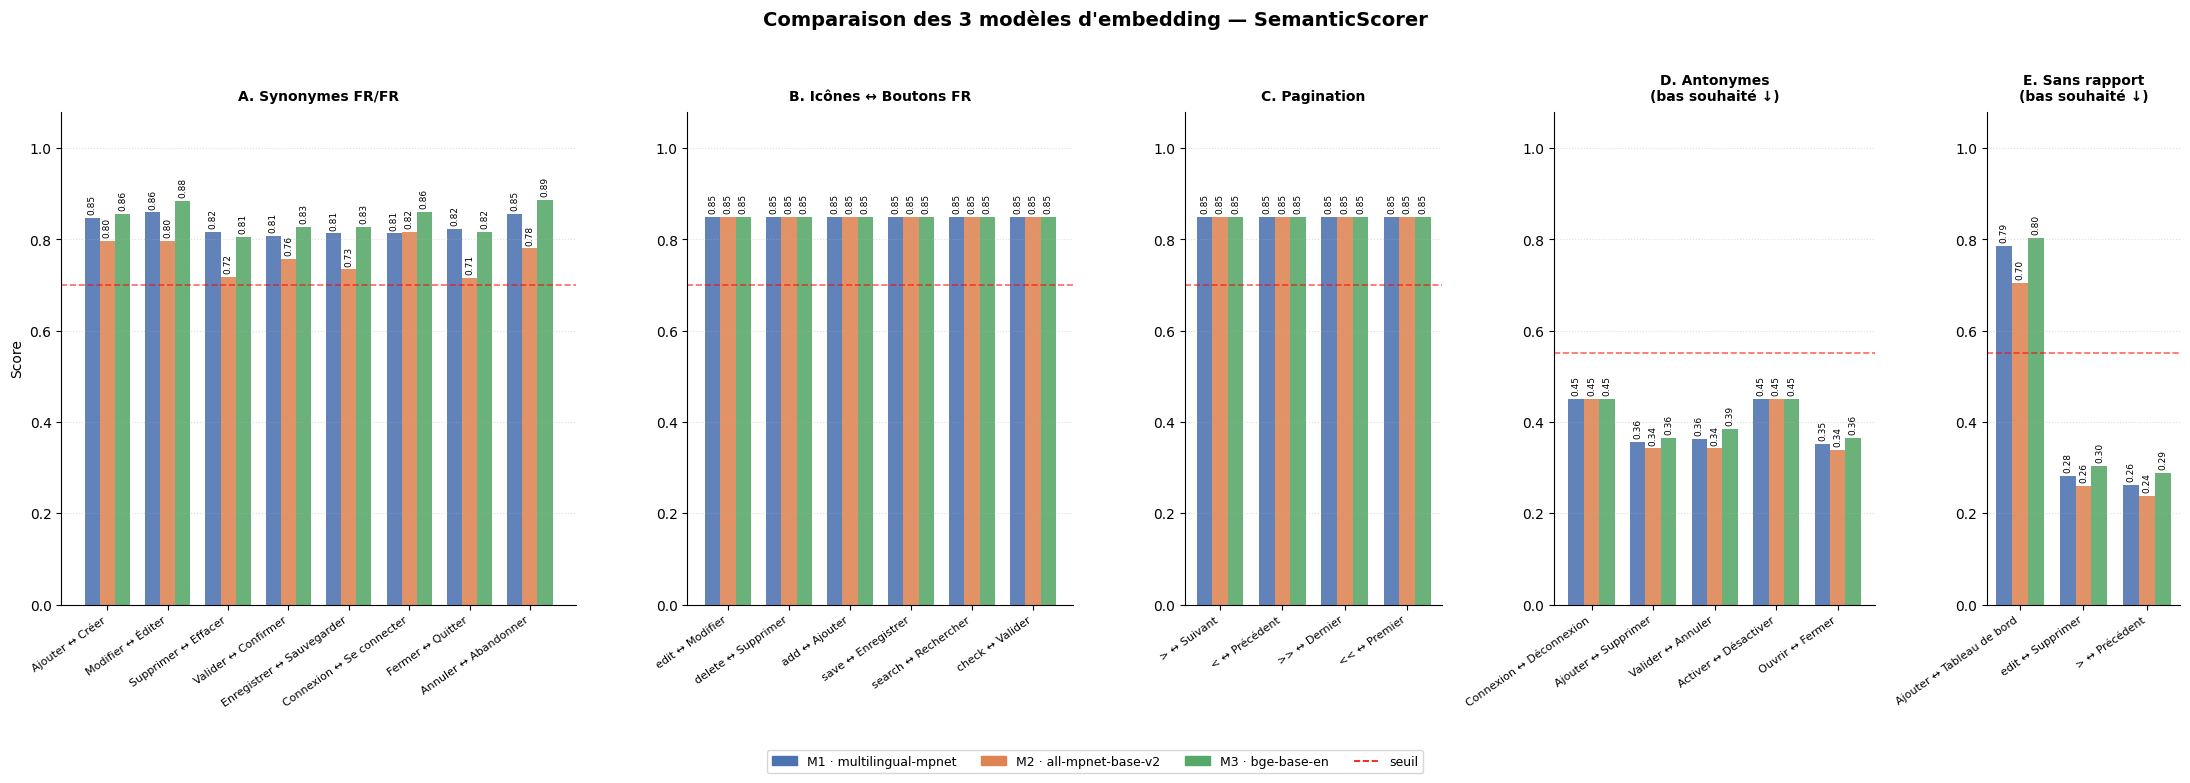

✅ Graphe sauvegardé : comparaison_3_modeles.png


In [16]:
# ============================================================
# CELL 10 — Visualisation comparative 3 modèles
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Données ──────────────────────────────────────────────────────────────────

categories = {
    "A. Synonymes FR/FR": [
        ("Ajouter ↔ Créer",          0.846, 0.797, 0.856),
        ("Modifier ↔ Éditer",         0.859, 0.796, 0.884),
        ("Supprimer ↔ Effacer",       0.816, 0.718, 0.805),
        ("Valider ↔ Confirmer",       0.808, 0.758, 0.828),
        ("Enregistrer ↔ Sauvegarder", 0.813, 0.734, 0.827),
        ("Connexion ↔ Se connecter",  0.813, 0.817, 0.861),
        ("Fermer ↔ Quitter",          0.823, 0.715, 0.817),
        ("Annuler ↔ Abandonner",      0.855, 0.780, 0.887),
    ],
    "B. Icônes ↔ Boutons FR": [
        ("edit ↔ Modifier",    0.850, 0.850, 0.850),
        ("delete ↔ Supprimer", 0.850, 0.850, 0.850),
        ("add ↔ Ajouter",      0.850, 0.850, 0.850),
        ("save ↔ Enregistrer", 0.850, 0.850, 0.850),
        ("search ↔ Rechercher",0.850, 0.850, 0.850),
        ("check ↔ Valider",    0.850, 0.850, 0.850),
    ],
    "C. Pagination": [
        ("> ↔ Suivant",   0.850, 0.850, 0.850),
        ("< ↔ Précédent", 0.850, 0.850, 0.850),
        (">> ↔ Dernier",  0.850, 0.850, 0.850),
        ("<< ↔ Premier",  0.850, 0.850, 0.850),
    ],
    "D. Antonymes\n(bas souhaité ↓)": [
        ("Connexion ↔ Déconnexion", 0.450, 0.450, 0.450),
        ("Ajouter ↔ Supprimer",     0.356, 0.342, 0.364),
        ("Valider ↔ Annuler",       0.363, 0.342, 0.385),
        ("Activer ↔ Désactiver",    0.450, 0.450, 0.450),
        ("Ouvrir ↔ Fermer",         0.352, 0.338, 0.364),
    ],
    "E. Sans rapport\n(bas souhaité ↓)": [
        ("Ajouter ↔ Tableau de bord", 0.785, 0.705, 0.803),
        ("edit ↔ Supprimer",          0.281, 0.259, 0.303),
        ("> ↔ Précédent",             0.261, 0.237, 0.289),
    ],
}

COLORS = {
    'M1': '#4C72B0',  # bleu   — multilingue
    'M2': '#DD8452',  # orange — all-mpnet
    'M3': '#55A868',  # vert   — bge
}
LABELS = {
    'M1': 'M1 · multilingual-mpnet',
    'M2': 'M2 · all-mpnet-base-v2',
    'M3': 'M3 · bge-base-en',
}

n_cats = len(categories)
fig, axes = plt.subplots(1, n_cats, figsize=(22, 7),
                         gridspec_kw={'width_ratios': [len(v) for v in categories.values()]})
fig.suptitle("Comparaison des 3 modèles d'embedding — SemanticScorer",
             fontsize=14, fontweight='bold', y=1.02)

for ax, (cat_name, rows) in zip(axes, categories.items()):

    labels  = [r[0] for r in rows]
    vals_m1 = [r[1] for r in rows]
    vals_m2 = [r[2] for r in rows]
    vals_m3 = [r[3] for r in rows]

    x      = np.arange(len(labels))
    width  = 0.25

    ax.bar(x - width, vals_m1, width, color=COLORS['M1'], alpha=0.88, label=LABELS['M1'])
    ax.bar(x,         vals_m2, width, color=COLORS['M2'], alpha=0.88, label=LABELS['M2'])
    ax.bar(x + width, vals_m3, width, color=COLORS['M3'], alpha=0.88, label=LABELS['M3'])

    # Seuil visuel selon la catégorie
    is_low = "souhaité" in cat_name
    threshold = 0.55 if is_low else 0.70
    ax.axhline(threshold, color='red', linewidth=1.2, linestyle='--', alpha=0.6,
               label=f"seuil {'max' if is_low else 'min'} {threshold}")

    # Valeurs au-dessus des barres
    for i, (m1, m2, m3) in enumerate(zip(vals_m1, vals_m2, vals_m3)):
        for offset, val in zip([-width, 0, width], [m1, m2, m3]):
            ax.text(i + offset, val + 0.008, f"{val:.2f}",
                    ha='center', va='bottom', fontsize=6.5, rotation=90)

    ax.set_title(cat_name, fontsize=10, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

# Légende commune en bas
patches = [mpatches.Patch(color=COLORS[k], label=LABELS[k]) for k in ('M1', 'M2', 'M3')]
patches.append(plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.2, label='seuil'))
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.08), frameon=True)

plt.tight_layout()
plt.savefig("comparaison_3_modeles.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphe sauvegardé : comparaison_3_modeles.png")

In [17]:
print('\n─── CAS 4 : Nouvelle requête (non présente en baseline) ────────────────')
_NEW_DOM_WITH_CANDIDATES = """
<html><body>
  <div class="q-toolbar">
    <input placeholder="Nom" type="text">
    <input placeholder="Email" type="email">
  </div>
</body></html>
"""

req_new = HealingRequest(
    old_locator = {"type": "xpath", "value": "//input[@placeholder='Prénom']"},
    old_element = ElementInfo(
        element_type = "input",
        text         = None,
        attributes   = {"placeholder": "Prénom", "type": "text"},
    ),
    current_dom = _NEW_DOM_WITH_CANDIDATES,
)

res_new = healing_engine.heal(req_new)
print(f"  success={res_new.success}  score={res_new.score:.3f}  locator={res_new.new_locator}")

print("\nALL TOP CANDIDATES for CAS 4:")
if res_new.candidates:
    for i, candidate in enumerate(res_new.candidates[:5]):
        print(f"  {i}: Score={candidate['score']:.3f}, Text='{candidate.get('text', 'N/A')}', XPath='{candidate['xpath']}'")

print("\n─── Métriques finales après CAS 4 ────────────────────────────────────")
m_after_new_req = healing_engine.metrics.to_dict()
bar = lambda v: "█" * int(v * 20) + "░" * (20 - int(v * 20))
print(f"  healing_rate      : {bar(m_after_new_req['healing_rate'])} {m_after_new_req['healing_rate']:.0%}")
print(f"  baseline_hit_rate : {bar(m_after_new_req['baseline_hit_rate'])} {m_after_new_req['baseline_hit_rate']:.0%}")
print(f"  nlp_efficiency    : {bar(m_after_new_req['nlp_filter_efficiency'])} {m_after_new_req['nlp_filter_efficiency']:.0%}")
print(f"  avg_time_ms       : {m_after_new_req['avg_healing_time_ms']:.1f} ms")
print(f"  avg_final_score   : {m_after_new_req['avg_final_score']:.3f}")
print(f"  struct_score avg  : {m_after_new_req['avg_structural_score']:.3f}")
print(f"  semantic_score avg: {m_after_new_req['avg_semantic_score']:.3f}")
print(f"  pipeline          : {m_after_new_req['total_elements_extracted']} extraits "
      f"\u2192 {m_after_new_req['total_sent_to_nlp']} NLP")


─── CAS 4 : Nouvelle requête (non présente en baseline) ────────────────
  → 2 éléments extraits (Quasar-aware v3)
  success=False  score=0.287  locator=None

ALL TOP CANDIDATES for CAS 4:
  0: Score=0.287, Text='Nom', XPath='//input[@aria-label='Nom']'
  1: Score=0.284, Text='Email', XPath='//input[@aria-label='Email']'

─── Métriques finales après CAS 4 ────────────────────────────────────
  healing_rate      : ░░░░░░░░░░░░░░░░░░░░ 0%
  baseline_hit_rate : ░░░░░░░░░░░░░░░░░░░░ 0%
  nlp_efficiency    : ░░░░░░░░░░░░░░░░░░░░ 0%
  avg_time_ms       : 3.6 ms
  avg_final_score   : 0.287
  struct_score avg  : 0.342
  semantic_score avg: 0.250
  pipeline          : 2 extraits → 2 NLP


# NGROK config

In [18]:
import json, threading, logging
import numpy as np
from flask import Flask, request, jsonify
from pyngrok import ngrok

from google.colab import userdata
import traceback # Added for debugging

logging.basicConfig(level=logging.WARNING)

def _np_safe(obj):
    """Sérialiseur numpy-safe pour jsonify."""
    if isinstance(obj, (np.floating,)):  return float(obj)
    if isinstance(obj, (np.integer,)):   return int(obj)
    if isinstance(obj, np.ndarray):      return obj.tolist()
    raise TypeError(f"Non sérialisable : {type(obj)}")

def safe_jsonify(data: dict):
    return jsonify(json.loads(json.dumps(data, default=_np_safe)))

# ── Flask app ────────────────────────────────────────────────────────────────
app = Flask(__name__)
app.config['MAX_CONTENT_LENGTH'] = 6 * 1024 * 1024   # 6 MB (pages Quasar lourdes)

# Added general exception handler for debugging
@app.errorhandler(Exception)
def handle_exception(e):
    app.logger.exception("Unhandled exception")
    return jsonify(success=False, error=str(e), traceback=traceback.format_exc()), 500

@app.route('/heal', methods=['POST'])
def heal_endpoint():
    raw = request.get_json(silent=True, force=True)
    # Added payload key logging for debugging
    if raw:
        app.logger.info(f"/heal payload keys: {list(raw.keys())}")

    if not raw:
        return jsonify({'success': False, 'error': 'JSON manquant ou malformé'}), 400
    try:
        heal_req = HealingRequest.from_dict(raw)
    except ValueError as ve:
        return jsonify({'success': False, 'error': str(ve)}), 422

    result = healing_engine.heal(heal_req)
    return safe_jsonify(result.to_dict()), 200


@app.route('/health', methods=['GET'])
def health_endpoint():
    return jsonify({
        'status':        'ok',
        'threshold':     healing_engine.threshold,
        'device':        semantic_scorer.device,
        'model':         'all-mpnet-base-v2',
        'quasar_aware':  True,
    })


@app.route('/metrics', methods=['GET'])
def metrics_endpoint():
    """Endpoint consommé par le dashboard Java."""
    return safe_jsonify(healing_engine.metrics.to_dict())


@app.route('/metrics/reset', methods=['POST'])
def metrics_reset():
    healing_engine.metrics = PerformanceMetrics()
    return jsonify({'status': 'ok', 'message': 'Métriques réinitialisées'})


# ── ngrok tunnel ─────────────────────────────────────────────────────────────

@app.route('/baseline', methods=['GET'])
def get_baseline():
    return jsonify(healing_baseline.stats())

@app.route('/baseline/clear', methods=['POST'])
def clear_baseline():
    n = healing_baseline.clear()
    return jsonify({"cleared": n, "status": "ok"})

@app.route('/baseline/invalidate', methods=['POST'])
def invalidate_baseline():
    raw = request.get_json(force=True, silent=True) or {}
    old_locator = raw.get('old_locator', {})
    current_dom = raw.get('current_dom', '')
    ok = healing_baseline.invalidate(old_locator, current_dom)
    return jsonify({"invalidated": ok})

@app.route('/baseline/export', methods=['GET'])
def export_baseline():
    props = healing_baseline.export_java_properties()
    return props, 200, {'Content-Type': 'text/plain; charset=utf-8'}

NGROK_TOKEN = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(NGROK_TOKEN)

# Kill any processes using port 5000 before starting the server
# This addresses the 'Address already in use' error on re-execution
!fuser -k 5000/tcp

public_url = ngrok.connect(5000).public_url

print("="*60)
print(f"🌍 API publique  : {public_url}")
print(f"   POST  {public_url}/heal")
print(f"   GET   {public_url}/health")
print(f"   GET   {public_url}/metrics")
print(f"   POST  {public_url}/metrics/reset")
print("="*60)
print(f"\n📋 config.properties :")
print(f"   self.healing.api.url={public_url}/heal")
print(f"   self.healing.metrics.url={public_url}/metrics")

def _run_flask():
    app.run(port=5000, debug=False, use_reloader=False, threaded=True)

threading.Thread(target=_run_flask, daemon=True).start()
print("\n🚀 Serveur prêt.")

🌍 API publique  : https://epigastric-troy-calculating.ngrok-free.dev
   POST  https://epigastric-troy-calculating.ngrok-free.dev/heal
   GET   https://epigastric-troy-calculating.ngrok-free.dev/health
   GET   https://epigastric-troy-calculating.ngrok-free.dev/metrics
   POST  https://epigastric-troy-calculating.ngrok-free.dev/metrics/reset

📋 config.properties :
   self.healing.api.url=https://epigastric-troy-calculating.ngrok-free.dev/heal
   self.healing.metrics.url=https://epigastric-troy-calculating.ngrok-free.dev/metrics

🚀 Serveur prêt.


In [19]:
import requests
u = "https://epigastric-troy-calculating.ngrok-free.dev/health"
r = requests.get(u, timeout=10)
print(r.status_code, r.text)

INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:25:10] "GET /health HTTP/1.1" 200 -


200 {"device":"cpu","model":"all-mpnet-base-v2","quasar_aware":true,"status":"ok","threshold":0.8}



In [20]:
import requests
requests.post("https://epigastric-troy-calculating.ngrok-free.dev/metrics/reset", timeout=10).text

INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:25:12] "POST /metrics/reset HTTP/1.1" 200 -


'{"message":"M\\u00e9triques r\\u00e9initialis\\u00e9es","status":"ok"}\n'

# Tests via URL

In [21]:
# -- Installation stable de Chrome pour Colab --
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google.list
!apt-get update
!apt-get install -y google-chrome-stable
!pip install selenium webdriver-manager --quiet

print("✅ Google Chrome Stable installé")

OK
Get:1 http://dl.google.com/linux/chrome/deb stable InRelease [1,825 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 http://dl.google.com/linux/chrome/deb stable/main amd64 Packages [1,213 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,247 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:14 ht

In [22]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

def create_driver():
    options = Options()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--window-size=1920,1080")

    # Enhanced Stealth Settings
    options.add_argument("user-agent=Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--lang=fr-FR")
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option("useAutomationExtension", False)

    try:
        service = Service(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=service, options=options)

        # Advanced CDP commands to spoof navigator properties
        driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
            "source": """
                Object.defineProperty(navigator, 'webdriver', {
                  get: () => undefined
                });
                window.chrome = {
                  runtime: {}
                };
                Object.defineProperty(navigator, 'languages', {
                  get: () => ['fr-FR', 'fr', 'en-US', 'en'],
                });
                Object.defineProperty(navigator, 'plugins', {
                  get: () => [1, 2, 3, 4, 5],
                });
            """
        })
        return driver
    except Exception as e:
        print(f"Error creating driver: {e}")
        raise e

### Prochaines étapes pour votre intégration Java :

1. Copiez l'URL **API publique** (ex: `https://...ngrok-free.dev`) dans votre fichier `config.properties` côté Java.
2. Assurez-vous que votre `SelfHealingClient.java` envoie bien le Header `Content-Type: application/json`.
3. Pour Noveocare, le moteur gérera automatiquement les IDs dynamiques Microsoft (`i0116`, `i0118`) en se basant sur le texte et la structure Quasar si l'ID change au runtime.

In [23]:
import requests
import json

# Ensure the public_url is available from the previous cell
# If you restarted the runtime, you might need to re-run Cell 8
if 'public_url' not in globals():
    print("Error: 'public_url' not found. Please run Cell 8 to start the Flask server and get the public URL.")
else:
    base_url = public_url

    print(f"Testing endpoints at: {base_url}")

    # Test /health endpoint
    health_url = f"{base_url}/health"
    try:
        print(f"\n--- Testing GET {health_url} ---")
        health_response = requests.get(health_url, timeout=10)
        print(f"Status Code: {health_response.status_code}")
        print(f"Response: {health_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to health endpoint: {e}")

    # Test /metrics endpoint
    metrics_url = f"{base_url}/metrics"
    try:
        print(f"\n--- Testing GET {metrics_url} ---")
        metrics_response = requests.get(metrics_url, timeout=10)
        print(f"Status Code: {metrics_response.status_code}")
        print(f"Response: {metrics_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to metrics endpoint: {e}")

    # Test /metrics/reset endpoint
    metrics_reset_url = f"{base_url}/metrics/reset"
    try:
        print(f"\n--- Testing POST {metrics_reset_url} ---")
        reset_response = requests.post(metrics_reset_url, timeout=10)
        print(f"Status Code: {reset_response.status_code}")
        print(f"Response: {reset_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to metrics reset endpoint: {e}")

    # Example for /heal endpoint (using dummy data, adapt as needed)
    heal_url = f"{base_url}/heal"
    dummy_healing_request = {
        "old_locator": {"type": "xpath", "value": "//button[normalize-space()='Old Button Text']"},
        "old_element": {
            "element_type": "button",
            "text": "Old Button Text",
            "attributes": {"class": "q-btn btn-primary"}
        },
        "current_dom": "<html><body><button>New Button Text</button></body></html>"
    }
    try:
        print(f"\n--- Testing POST {heal_url} ---")
        heal_response = requests.post(heal_url, json=dummy_healing_request, timeout=10)
        print(f"Status Code: {heal_response.status_code}")
        print(f"Response: {heal_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to heal endpoint: {e}")

    # Test /baseline endpoint
    baseline_url = f"{base_url}/baseline"
    try:
        print(f"\n--- Testing GET {baseline_url} ---")
        baseline_response = requests.get(baseline_url, timeout=10)
        print(f"Status Code: {baseline_response.status_code}")
        print(f"Response: {baseline_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to baseline endpoint: {e}")

    # Test /baseline/export endpoint
    baseline_export_url = f"{base_url}/baseline/export"
    try:
        print(f"\n--- Testing GET {baseline_export_url} ---")
        baseline_export_response = requests.get(baseline_export_url, timeout=10)
        print(f"Status Code: {baseline_export_response.status_code}")
        print(f"Response (first 200 chars): {baseline_export_response.text[:200]}...")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to baseline export endpoint: {e}")

    # Test /baseline/clear endpoint
    baseline_clear_url = f"{base_url}/baseline/clear"
    try:
        print(f"\n--- Testing POST {baseline_clear_url} ---")
        baseline_clear_response = requests.post(baseline_clear_url, timeout=10)
        print(f"Status Code: {baseline_clear_response.status_code}")
        print(f"Response: {baseline_clear_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to baseline clear endpoint: {e}")

    # Test /baseline/invalidate endpoint (example)
    baseline_invalidate_url = f"{base_url}/baseline/invalidate"
    dummy_invalidate_request = {
        "old_locator": {"type": "xpath", "value": "//button[normalize-space()='Ajouter un Environnement']"},
        "current_dom": "<html><body><button>Créer un Environnement</button></body></html>"
    }
    try:
        print(f"\n--- Testing POST {baseline_invalidate_url} ---")
        baseline_invalidate_response = requests.post(baseline_invalidate_url, json=dummy_invalidate_request, timeout=10)
        print(f"Status Code: {baseline_invalidate_response.status_code}")
        print(f"Response: {baseline_invalidate_response.json()}")
    except requests.exceptions.RequestException as e:
        print(f"Error connecting to baseline invalidate endpoint: {e}")


Testing endpoints at: https://epigastric-troy-calculating.ngrok-free.dev

--- Testing GET https://epigastric-troy-calculating.ngrok-free.dev/health ---


INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:26:20] "GET /health HTTP/1.1" 200 -


Status Code: 200
Response: {'device': 'cpu', 'model': 'all-mpnet-base-v2', 'quasar_aware': True, 'status': 'ok', 'threshold': 0.8}

--- Testing GET https://epigastric-troy-calculating.ngrok-free.dev/metrics ---


INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:26:21] "GET /metrics HTTP/1.1" 200 -


Status Code: 200
Response: {'accumulated_scores': 0.0, 'accumulated_semantic_scores': 0.0, 'accumulated_struct_scores': 0.0, 'avg_final_score': 0.0, 'avg_healing_time_ms': 0.0, 'avg_semantic_score': 0.0, 'avg_structural_score': 0.0, 'baseline_hit_rate': 0.0, 'baseline_hits': 0, 'failed_healings': 0, 'healing_rate': 0.0, 'nlp_filter_efficiency': 0.0, 'successful_healings': 0, 'total_after_spatial_filter': 0, 'total_after_struct_filter': 0, 'total_elements_extracted': 0, 'total_healing_requests': 0, 'total_healing_time_ms': 0.0, 'total_sent_to_nlp': 0}

--- Testing POST https://epigastric-troy-calculating.ngrok-free.dev/metrics/reset ---


...

Status Code: 200
Response (first 200 chars): # Auto-generated by HealingBaseline — DO NOT EDIT...

--- Testing POST https://epigastric-troy-calculating.ngrok-free.dev/baseline/clear ---


INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:26:25] "POST /baseline/clear HTTP/1.1" 200 -


  [Baseline] 🧹 Effacé : 0 entrées supprimées
Status Code: 200
Response: {'cleared': 0, 'status': 'ok'}

--- Testing POST https://epigastric-troy-calculating.ngrok-free.dev/baseline/invalidate ---


INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:26:25] "POST /baseline/invalidate HTTP/1.1" 200 -


Status Code: 200
Response: {'invalidated': False}


In [24]:
# import requests

# # Ensure public_url is available
# if 'public_url' not in globals():
#     print("Error: 'public_url' not found. Please run the cell that starts the Flask server to get the public URL.")
# else:
#     baseline_clear_url = f"{public_url}/baseline/clear"
#     print(f"\n--- Clearing baseline at {baseline_clear_url} ---")
#     try:
#         clear_response = requests.post(baseline_clear_url, timeout=10)
#         print(f"Status Code: {clear_response.status_code}")
#         print(f"Response: {clear_response.json()}")
#     except requests.exceptions.RequestException as e:
#         print(f"Error connecting to baseline clear endpoint: {e}")

### Testing `/heal` endpoint with Python `requests`

This test will construct the `HealingRequest` body in Python, serialize it to JSON, and send it to the `/heal` endpoint using the `requests` library. This helps to determine if the issue is with the JSON data structure or the PowerShell client.

In [25]:
import requests
import json

# Ensure public_url is available
if 'public_url' not in globals():
    print("Error: 'public_url' not found. Please run Cell 8 to start the Flask server and get the public URL.")
else:
    heal_url = f"{public_url}/heal"

    # Reconstruct the body similar to the PowerShell example
    python_healing_request_body = {
        "old_locator": {
            "type": "id",
            "value": "login-submit-btn-connect-to-application"
        },
        "old_element": {
            "element_id": "login-submit-btn-connect-to-application",
            "element_type": "button",
            "text": "Se connecter",
            "attributes": {
                "id": "login-submit-btn-connect-to-application",
                "class": "q-btn"
            },
            "xpath": "//button[@id='login-submit-btn-connect-to-application']"
        },
        "current_dom": "<html><body><button id='login-submit-btn-connect-to-application-v2'>Se connecter</button></body></html>"
    }

    print(f"\n--- Testing POST {heal_url} with Python requests ---")
    try:
        # Send the JSON directly using the 'json' parameter of requests.post
        # requests handles content-type and serialization automatically
        python_heal_response = requests.post(heal_url, json=python_healing_request_body, timeout=10)
        print(f"Status Code: {python_heal_response.status_code}")
        print(f"Response: {python_heal_response.json()}")

        # Also try with explicit data and headers, to mimic Invoke-RestMethod more closely
        print("\n--- Trying with explicit data and headers ---")
        explicit_headers = {'Content-Type': 'application/json'}
        explicit_heal_response = requests.post(
            heal_url,
            data=json.dumps(python_healing_request_body, ensure_ascii=False),
            headers=explicit_headers,
            timeout=10
        )
        print(f"Status Code (explicit): {explicit_heal_response.status_code}")
        print(f"Response (explicit): {explicit_heal_response.json()}")


    except requests.exceptions.RequestException as e:
        print(f"Error connecting to heal endpoint with Python requests: {e}")



--- Testing POST https://epigastric-troy-calculating.ngrok-free.dev/heal with Python requests ---


INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:26:29] "POST /heal HTTP/1.1" 200 -


  → 1 éléments extraits (Quasar-aware v3)
Status Code: 200
Response: {'candidates': [{'score': 0.802, 'text': 'Se connecter', 'xpath': "//button[@id='login-submit-btn-connect-to-application-v2']"}], 'details': {}, 'error': None, 'new_locator': {'type': 'xpath', 'value': "//button[@id='login-submit-btn-connect-to-application-v2']"}, 'score': 0.802, 'success': True}

--- Trying with explicit data and headers ---


INFO:werkzeug:127.0.0.1 - - [13/May/2026 09:26:30] "POST /heal HTTP/1.1" 200 -


  → 1 éléments extraits (Quasar-aware v3)
Status Code (explicit): 200
Response (explicit): {'candidates': [{'score': 0.802, 'text': 'Se connecter', 'xpath': "//button[@id='login-submit-btn-connect-to-application-v2']"}], 'details': {}, 'error': None, 'new_locator': {'type': 'xpath', 'value': "//button[@id='login-submit-btn-connect-to-application-v2']"}, 'score': 0.802, 'success': True}


In [26]:
import requests
import json

# The current DOM provided by the user
current_dom_user = '''<html dir="ltr" lang="en-US"><head><title>BackOffice Noveocare</title><meta charset="utf-8"><meta name="description" content="A Quasar Project"><meta name="format-detection" content="telephone=no"><meta name="msapplication-tap-highlight" content="no"><meta name="viewport" content="user-scalable=no,initial-scale=1,maximum-scale=1,minimum-scale=1,width=device-width"><link id="favicon" rel="icon" type="image/ico" href="/config/noveocare/favicon.png">  <script type="module" crossorigin="" src="/assets/index.b58d9101.js"></script>
  <link rel="stylesheet" href="/assets/index.1a276edf.css">
<link rel="modulepreload" as="script" crossorigin="" href="/assets/MainLayout.5780ec58.js"><link rel="stylesheet" href="/assets/MainLayout.e659c7d0.css"><link rel="modulepreload" as="script" crossorigin="" href="/assets/format.1a17be21.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QDrawer.75248042.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/TouchPan.51c6f213.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/touch.9135741d.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QLayout.7a6b7ebe.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QScrollObserver.8d5d7cb9.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QResizeObserver.c1b983eb.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/use-quasar.444eddf4.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/DataTable.vue_vue_type_style_index_0_scoped_true_lang.bbf7d43d.js"><link rel="stylesheet" href="/assets/DataTable.vue_vue_type_style_index_0_scoped_true_lang.33eb4029.css"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QTr.266914cf.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QImg.eb103beb.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/NcBtn.812871f2.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/AlertCard.c4e9c146.js"><link rel="stylesheet" href="/assets/AlertCard.e9ab73c1.css"><link rel="modulepreload" as="script" crossorigin="" href="/assets/index.6ea52d11.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/Dashboard.b6296dae.js"><link rel="stylesheet" href="/assets/Dashboard.35503eae.css"><link rel="modulepreload" as="script" crossorigin="" href="/assets/QPage.e56ee7da.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/ConfirmDialog.fb1055e3.js"><link rel="modulepreload" as="script" crossorigin="" href="/assets/ContactCard.6aa688b2.js"><link rel="stylesheet" href="/assets/ContactCard.da9c4586.css"><link rel="modulepreload" as="script" crossorigin="" href="/assets/Login.f36ffcd4.js"></head><body class="desktop no-touch body--light"><div id="q-app" data-v-app=""><div class="q-layout q-layout--standard" tabindex="-1" style="min-height: 920px;"><!----><!----><div class="q-page-container"><main class="q-page login row q-mx-auto" style="min-height: 920px;"><div class="row col-md-12 col-xs-12 q-my-xl" style="min-height: 100%; margin-top: 15%;"><div class="router row col-md-12 col-sm-12 col-xs-12 q-mx-auto justify-center q-mt-auto q-mb-auto"><div class="col-md-12 col-xs-12 q-px-lg q-my-lg"><div class="row q-mx-auto justify-center"><div class="q-avatar bg-info-50 text-center q-mx-auto" style="font-size: 50px;"><div class="q-avatar__content row flex-center overflow-hidden"><i class="q-icon icon-user text-success-700 icon-size-md text-weight-semi-bold" aria-hidden="true"> </i></div></div></div><div class="row"><h2 class="col-md-3 col-xs-12 col-sm-6 text-gray-900 q-mx-auto text-h2 text-weight-semi-bold text-center">Bienvenue sur le Backoffice Noveocare</h2><div class="col-12 text-center text-gray-500 text-weight-light text-subtitle1">Cliquez sur le bouton ci-dessous pour vous</div><div class="col-12 q-mx-auto text-center text-gray-500 text-weight-light text-subtitle1">connecter grâce à votre compte Outlook</div><div class="q-mx-auto col-md-4 col-xs-12 col-sm-6 q-mt-md"><button class="q-btn q-btn-item non-selectable no-outline q-btn--standard q-btn--rectangle q-btn--actionable q-focusable q-hoverable q-btn--no-uppercase btn-primary col-12 btn-radius-md cursor-pointer full-width bg-info-700 text-white" tabindex="0" type="button" id="login-submit-btn-connect-to-application" large="" hide-bottom-space="true"><span class="q-focus-helper"></span><span class="q-btn__content text-center col items-center q-anchor--skip justify-center row"><span class="text-subtitle1 q-my-xs text-weight-semi-bold">Se connecter avec mon compte Noveocare</span></span></button></div></div></div></div></div></main></div></div></div><div id="q-notify" data-v-app=""><div class="q-notifications"><div class="q-notifications__list q-notifications__list--top fixed column no-wrap items-start"></div><div class="q-notifications__list q-notifications__list--top fixed column no-wrap items-end"></div><div class="q-notifications__list q-notifications__list--bottom fixed column no-wrap items-start"></div><div class="q-notifications__list q-notifications__list--bottom fixed column no-wrap items-end"></div><div class="q-notifications__list q-notifications__list--top fixed column no-wrap items-center"></div><div class="q-notifications__list q-notifications__list--bottom fixed column no-wrap items-center"></div><div class="q-notifications__list q-notifications__list--center fixed column no-wrap items-start justify-center"></div><div class="q-notifications__list q-notifications__list--center fixed column no-wrap items-end justify-center"></div><div class="q-notifications__list q-notifications__list--center fixed column no-wrap flex-center"></div></div></div></body></html>'''

# Construct the HealingRequest
# old_locator is the broken one
# old_element describes the *expected* element based on its original, correct state

login_healing_request = HealingRequest(
    old_locator={
        "type": "id",
        "value": "login-submit-btn-connect-to-application-broken" # This is the broken locator
    },
    old_element=ElementInfo(
        element_id="login-submit-btn-connect-to-application", # The actual ID if it wasn't broken
        element_type="button",
        text="Se connecter avec mon compte Noveocare",
        attributes={
            "class": "q-btn q-btn-item non-selectable no-outline q-btn--standard q-btn--rectangle q-btn--actionable q-focusable q-hoverable q-btn--no-uppercase btn-primary col-12 btn-radius-md cursor-pointer full-width bg-info-700 text-white",
            "tabindex": "0",
            "type": "button",
            "id": "login-submit-btn-connect-to-application",
            "large": "",
            "hide-bottom-space": "true"
        },
        xpath="//button[@id='login-submit-btn-connect-to-application']"
    ),
    current_dom=current_dom_user
)

print("\n--- Testing healing with broken login button locator ---")
res_login = healing_engine.heal(login_healing_request)

print(f"  success={{res_login.success}}  score={{res_login.score:.3f}}  locator={{res_login.new_locator}}")

if res_login.candidates:
    print("\nTop candidates:")
    for i, candidate in enumerate(res_login.candidates):
        print(f"  {{i+1}}. Score={{candidate['score']:.3f}}, Text='{{candidate['text']}}', XPath='{{candidate['xpath']}}'")
else:
    print("\nNo candidates found (may be a baseline hit or healing failed early).")

print("\n--- Metrics after this test ---")
m_after_login_test = healing_engine.metrics.to_dict()
bar = lambda v: "█" * int(v * 20) + "░" * (20 - int(v * 20))
print(f"  healing_rate      : {{bar(m_after_login_test['healing_rate'])}} {{m_after_login_test['healing_rate']:.0%}}")
print(f"  baseline_hit_rate : {{bar(m_after_login_test['baseline_hit_rate'])}} {{m_after_login_test['baseline_hit_rate']:.0%}}")
print(f"  veto_rate         : {{bar(m_after_login_test['veto_rate'])}} {{m_after_login_test['veto_rate']:.0%}}")
print(f"  avg_time_ms       : {{m_after_login_test['avg_healing_time_ms']:.1f}} ms")
print(f"  avg_final_score   : {{m_after_login_test['avg_final_score']:.3f}}")


--- Testing healing with broken login button locator ---
  → 1 éléments extraits (Quasar-aware v3)
  success={res_login.success}  score={res_login.score:.3f}  locator={res_login.new_locator}

Top candidates:
  {i+1}. Score={candidate['score']:.3f}, Text='{candidate['text']}', XPath='{candidate['xpath']}'

--- Metrics after this test ---
  healing_rate      : {bar(m_after_login_test['healing_rate'])} {m_after_login_test['healing_rate']:.0%}
  baseline_hit_rate : {bar(m_after_login_test['baseline_hit_rate'])} {m_after_login_test['baseline_hit_rate']:.0%}
  veto_rate         : {bar(m_after_login_test['veto_rate'])} {m_after_login_test['veto_rate']:.0%}
  avg_time_ms       : {m_after_login_test['avg_healing_time_ms']:.1f} ms
  avg_final_score   : {m_after_login_test['avg_final_score']:.3f}


In [27]:
import requests
import json

# current_dom_user est défini dans la cellule précédente

# Définissons un 'old_locator' cassé et le 'old_element' tel qu'il était censé être.
broken_healing_request = HealingRequest(
    old_locator={
        "type": "id",
        "value": "login-submit-btn-connect-to-application-typo" # ID intentionnellement incorrect
    },
    old_element=ElementInfo(
        element_id="login-submit-btn-connect-to-application",
        element_type="button",
        text="Se connecter avec mon compte Noveocare",
        attributes={
            "class": "q-btn q-btn-item non-selectable no-outline q-btn--standard q-btn--rectangle q-btn--actionable q-focusable q-hoverable q-btn--no-uppercase btn-primary col-12 btn-radius-md cursor-pointer full-width bg-info-700 text-white",
            "tabindex": "0",
            "type": "button",
            "id": "login-submit-btn-connect-to-application",
            "large": "",
            "hide-bottom-space": "true"
        },
        xpath="//button[@id='login-submit-btn-connect-to-application']"
    ),
    current_dom=current_dom_user
)

print("\n--- Test de guérison avec un localisateur cassé pour le bouton de connexion ---")
res_broken = healing_engine.heal(broken_healing_request)

print(f"  Succès: {res_broken.success} | Score: {res_broken.score:.3f} | Nouveau localisateur: {res_broken.new_locator}")

if not res_broken.success:
    print(f"  Erreur: {res_broken.error}")
else:
    print("  Le localisateur a été guéri avec succès !")

print("\n--- Métriques après ce test ---")
m_after_broken_test = healing_engine.metrics.to_dict()
bar = lambda v: "█" * int(v * 20) + "░" * (20 - int(v * 20))
print(f"  healing_rate      : {bar(m_after_broken_test['healing_rate'])} {m_after_broken_test['healing_rate']:.0%}")
print(f"  baseline_hit_rate : {bar(m_after_broken_test['baseline_hit_rate'])} {m_after_broken_test['baseline_hit_rate']:.0%}")
print(f"  nlp_efficiency    : {bar(m_after_broken_test['nlp_filter_efficiency'])} {m_after_broken_test['nlp_filter_efficiency']:.0%}")
print(f"  avg_time_ms       : {m_after_broken_test['avg_healing_time_ms']:.1f} ms")
print(f"  avg_final_score   : {m_after_broken_test['avg_final_score']:.3f}")


--- Test de guérison avec un localisateur cassé pour le bouton de connexion ---
  → 1 éléments extraits (Quasar-aware v3)
  Succès: True | Score: 0.844 | Nouveau localisateur: {'type': 'xpath', 'value': "//button[@id='login-submit-btn-connect-to-application']"}
  Le localisateur a été guéri avec succès !

--- Métriques après ce test ---
  healing_rate      : ████████████████░░░░ 80%
  baseline_hit_rate : ░░░░░░░░░░░░░░░░░░░░ 0%
  nlp_efficiency    : ░░░░░░░░░░░░░░░░░░░░ 0%
  avg_time_ms       : 148.5 ms
  avg_final_score   : 0.803


### Correction: `old_element.element_type` should be 'button'

Below is the corrected `HealingRequest` where `old_element.element_type` is set to `"button"`. This should resolve the 'Aucun candidat structurellement compatible' error.

In [28]:
import requests
import json

# Corrected HealingRequest with element_type set to 'button'
corrected_healing_request = HealingRequest(
    old_locator={
        "type": "id",
        "value": "login-submit-btn-connect-to-application-broken"
    },
    old_element=ElementInfo(
        element_id="login-submit-btn-connect-to-application",
        element_type="button",
        text="Se connecter avec mon compte Noveocare",
        attributes={
            "class": "q-btn q-btn-item non-selectable no-outline q-btn--standard q-btn--rectangle q-btn--actionable q-focusable q-hoverable q-btn--no-uppercase btn-primary col-12 btn-radius-md cursor-pointer full-width bg-info-700 text-white",
            "id": "login-submit-btn-connect-to-application"
        },
        xpath="//button[@id='login-submit-btn-connect-to-application']"
    ),
    current_dom=current_dom_user
)

print("\n--- Test healing with CORRECTED old_element.element_type ---")
res_corrected = healing_engine.heal(corrected_healing_request)

print(f"  Success: {res_corrected.success} | Score: {res_corrected.score:.3f} | New locator: {res_corrected.new_locator}")

print("\n--- Metrics after this corrected test ---")
m_after_corrected_test = healing_engine.metrics.to_dict()
bar = lambda v: "█" * int(v * 20) + "░" * (20 - int(v * 20))
print(f"  healing_rate      : {bar(m_after_corrected_test['healing_rate'])} {m_after_corrected_test['healing_rate']:.0%}")
print(f"  baseline_hit_rate : {bar(m_after_corrected_test['baseline_hit_rate'])} {m_after_corrected_test['baseline_hit_rate']:.0%}")
print(f"  nlp_efficiency    : {bar(m_after_corrected_test['nlp_filter_efficiency'])} {m_after_corrected_test['nlp_filter_efficiency']:.0%}")
print(f"  avg_time_ms       : {m_after_corrected_test['avg_healing_time_ms']:.1f} ms")
print(f"  avg_final_score   : {m_after_corrected_test['avg_final_score']:.3f}")


--- Test healing with CORRECTED old_element.element_type ---
  → 1 éléments extraits (Quasar-aware v3)
  Success: True | Score: 0.802 | New locator: {'type': 'xpath', 'value': "//button[@id='login-submit-btn-connect-to-application']"}

--- Metrics after this corrected test ---
  healing_rate      : ████████████████░░░░ 83%
  baseline_hit_rate : ░░░░░░░░░░░░░░░░░░░░ 0%
  nlp_efficiency    : ░░░░░░░░░░░░░░░░░░░░ 0%
  avg_time_ms       : 124.7 ms
  avg_final_score   : 0.803
